# Notebook- Proyecto de Ingeniería II: Artery-VA

## 1. Configuración del entorno de trabajo

Montamos Google Drive y configuramos las rutas. El dataset vive en /content/DATA_R1_R2_LIMPIO_COPIA_ENTRENAMIENTO.csv

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = '/content/DATA_R1_R2_LIMPIO_COPIA_ENTRENAMIENTO.csv'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Entorno listo')

Mounted at /content/drive
Entorno listo


## 2. Carga del dataset

In [3]:
df = pd.read_csv(DATA_PATH, sep=';')
print(f'Registros: {len(df):,}   |   Columnas: {df.shape[1]}')
df.head()

Registros: 1,813   |   Columnas: 31


,id,acido_urico,c_total,creatinina,celulas_medias,glucosa,granulocitos,hdl,hematocrito,hemoglobina,...,ap_hipertension,af_diabetes,af_hipertension,ta_sistolica,ta_diastolica,peso,talla,imc,TFG,Estadio_TFG
0,1,NaN,NaN,0.5,1.0,NaN,58.0,NaN,45.0,15.0,...,0.0,0.0,0.0,111.0,73.0,88.7,154.0,37.40,132.64,1.0
1,2,NaN,NaN,NaN,3.0,NaN,63.0,NaN,45.0,15.0,...,0.0,0.0,0.0,110.0,70.0,56.0,158.0,22.43,NaN,NaN
2,3,NaN,227.0,0.9,NaN,79.0,NaN,45.4,NaN,NaN,...,0.0,0.0,0.0,110.0,70.0,65.0,160.0,25.39,107.97,1.0
3,4,NaN,186.0,0.6,3.0,88.0,67.0,37.2,45.0,15.0,...,0.0,NaN,NaN,NaN,NaN,63.0,160.0,24.61,127.58,1.0
4,5,NaN,122.0,1.0,1.0,89.0,65.0,24.4,44.0,14.6,...,0.0,0.0,0.0,110.0,70.0,62.7,162.0,23.89,103.41,1.0


## 3. Limpieza #1

En esta sección se realiza una limpieza superficial de los datos. Primero, se eliminan las filas duplicadas. Posteriormente, los valores absurdos, tanto clínicos como estadísticos, se convierten en datos nulos (`NaN`) para ser imputados más adelante. Además, las variables o columnas que contienen más del 50% de datos faltantes son eliminadas con el fin de reducir el ruido y mejorar el desempeño del modelo. Finalmente, se imprime un resumen general de esta primera etapa de limpieza y el conjunto de datos procesado se guarda para su uso posterior.


In [4]:
# Define DATA_PATH explicitly within this cell to ensure it's always available.
DATA_PATH = '/content/DATA_R1_R2_LIMPIO_COPIA_ENTRENAMIENTO.csv'

#  1. Eliminamos los datos duplicados
df = pd.read_csv(DATA_PATH, sep=';') # Re-initialize df to ensure it's defined
df = df.drop_duplicates()
print(f"Filas tras eliminar duplicados: {len(df)}")

#  2. Los valores absurdos tanto clinicos como estadisticos se convierten en NaN
rangos = {
    'acido_urico':    (1.5, 20),
    'c_total':        (50, 500),
    'creatinina':     (0.3, 20),
    'glucosa':        (30, 600),
    'hdl':            (10, 150),
    'hematocrito':    (10, 65),
    'hemoglobina':    (3, 25),
    'ldl':            (10, 400),
    'trigliceridos':  (20, 1000),
    'edad':           (0, 110),
    'ta_sistolica':   (60, 250),
    'ta_diastolica':  (30, 150),
    'peso':           (20, 200),
    'talla':          (100, 220),
    'imc':            (10, 70),
    'TFG':            (1, 200),
}

print("\nValores convertidos a  NaN")
for col, (minv, maxv) in rangos.items():
    if col not in df.columns:
        continue
    mask = (df[col] < minv) | (df[col] > maxv)
    n = mask.sum()
    if n > 0:
        print(f"  {col}: {n} valores fuera de [{minv}, {maxv}] → NaN")
        df.loc[mask, col] = np.nan

#  3. Aquellas variables/columnas que tienen mas del 50% de datos NaN, se eliminan
cols_altas = [c for c in df.columns if df[c].isnull().mean() > 0.5]
print(f"\n Columnas eliminadas")
for c in cols_altas:
    print(f"  {c}: {df[c].isnull().mean()*100:.1f}% nulos")
df = df.drop(columns=cols_altas)

#  4. Resumen
print(f"\nResumen final")
print(f"Filas: {len(df)}  |  Columnas: {len(df.columns)}")
print("\n% Nulos restantes:")
pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(pct[pct > 0].round(1).to_string())

#  5. Guardar
df.to_csv("datos_limpios.csv", index=False, sep=';')
print("\nGuardado: datos_limpios.csv")

Filas tras eliminar duplicados: 1813

Valores convertidos a  NaN
  acido_urico: 1 valores fuera de [1.5, 20] → NaN
  c_total: 4 valores fuera de [50, 500] → NaN
  creatinina: 19 valores fuera de [0.3, 20] → NaN
  glucosa: 4 valores fuera de [30, 600] → NaN
  hematocrito: 3 valores fuera de [10, 65] → NaN
  hemoglobina: 12 valores fuera de [3, 25] → NaN
  ldl: 1 valores fuera de [10, 400] → NaN
  trigliceridos: 1 valores fuera de [20, 1000] → NaN
  ta_sistolica: 14 valores fuera de [60, 250] → NaN
  ta_diastolica: 12 valores fuera de [30, 150] → NaN
  peso: 73 valores fuera de [20, 200] → NaN
  talla: 58 valores fuera de [100, 220] → NaN
  imc: 46 valores fuera de [10, 70] → NaN
  TFG: 16 valores fuera de [1, 200] → NaN

 Columnas eliminadas
  acido_urico: 88.1% nulos

Resumen final
Filas: 1813  |  Columnas: 30

% Nulos restantes:
ldl                           38.7
hdl                           37.2
Estadio_TFG                   26.7
creatinina                    26.2
TFG               

## 4. EDA- Analisis Exploratorio de Datos

En esta sección se realiza una revisión exploratoria de los datos con el fin de identificar qué información puede depurarse y qué variables aportan valor al análisis. El análisis exploratorio de datos (EDA) se divide en análisis univariado, bivariado y multivariado. A través de este proceso se evalúa la distribución de las variables, las relaciones entre ellas y los posibles patrones presentes en el conjunto de datos. Además, se identifican variables altamente correlacionadas entre sí, las cuales pueden considerarse redundantes y, por tanto, no necesarias en etapas posteriores del procesamiento y modelado.


### 1. Tipo de datos

En esta sección se imprime el tipo de dato correspondiente a cada variable del conjunto de datos, permitiendo identificar si se trata de variables numéricas flotantes (`float`), enteras (`int`) o de tipo texto/carácter (`string`). Esto facilita la verificación de consistencia en los datos y permite determinar qué transformaciones o tratamientos son necesarios en etapas posteriores del procesamiento.


In [5]:
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Valores nulos por columna ===')
print(df.isnull().sum())

=== Tipos de datos ===
id                              int64
c_total                       float64
creatinina                    float64
celulas_medias                float64
glucosa                       float64
granulocitos                  float64
hdl                           float64
hematocrito                   float64
hemoglobina                   float64
ldl                           float64
leucocitos                    float64
linfocitos                    float64
plaquetas                     float64
trigliceridos                 float64
edad                            int64
sexo                            int64
zona                            int64
cigarrillo_cantidad_diaria    float64
alcohol_anos_uso              float64
ap_diabetes                   float64
ap_hipertension               float64
af_diabetes                   float64
af_hipertension               float64
ta_sistolica                  float64
ta_diastolica                 float64
peso                       

### 2. Descripción de variables

En esta sección se especifica la forma en que están codificadas las variables del conjunto de datos. Se identifican variables binarias codificadas, por ejemplo, con valores 0 y 1 para representar respuestas como “sí/no” o categorías como “hombre/mujer”. Además, se describe el significado de cada variable y de sus respectivas codificaciones en términos clínicos y médicos, con el fin de facilitar la interpretación adecuada de los datos durante el análisis y modelado.



| Variable | Descripción |
|---|---|
| id | Identificador único del paciente — se descarta antes de entrenar |
| c_total | Colesterol total (mg/dL) |
| creatinina | Nivel de creatinina en sangre (mg/dL) — indicador de función renal |
| celulas_medias | Células de tamaño medio en hemograma |
| glucosa | Nivel de glucosa en sangre (mg/dL) |
| granulocitos | Conteo de granulocitos (% o valor absoluto) |
| hdl | Colesterol HDL — lipoproteína de alta densidad (mg/dL) |
| hematocrito | Porcentaje de glóbulos rojos en sangre (%) |
| hemoglobina | Concentración de hemoglobina en sangre (g/dL) |
| ldl | Colesterol LDL — lipoproteína de baja densidad (mg/dL) |
| leucocitos | Conteo total de glóbulos blancos (10³/µL) |
| linfocitos | Conteo de linfocitos (% o valor absoluto) |
| plaquetas | Conteo de plaquetas (10³/µL) |
| trigliceridos | Nivel de triglicéridos en sangre (mg/dL) |
| edad | Edad del paciente en años |
| sexo | Sexo biológico · 0 = femenino · 1 = masculino |
| zona | Zona geográfica o de residencia 0 = rural 1 = urbana |
| cigarrillo_cantidad_diaria | Número de cigarrillos consumidos por día |
| alcohol_anos_uso | Años de consumo de alcohol |
| ap_diabetes | Antecedente personal de diabetes · 0 = no · 1 = sí |
| ap_hipertension | Antecedente personal de hipertensión · 0 = no · 1 = sí |
| af_diabetes | Antecedente familiar de diabetes · 0 = no · 1 = sí |
| af_hipertension | Antecedente familiar de hipertensión · 0 = no · 1 = sí |
| ta_sistolica | Tensión arterial sistólica (mmHg) |
| ta_diastolica | Tensión arterial diastólica (mmHg) |
| peso | Peso corporal (kg) |
| talla | Talla o estatura (cm) |
| imc | Índice de Masa Corporal = peso / talla² (kg/m²) |
| TFG | Tasa de Filtración Glomerular — función renal (mL/min/1.73m²) |
"""

display(Markdown(tabla))

### 3. Analisis univariado

En esta etapa se analizan medidas estadísticas descriptivas como media, mediana, desviación estándar, valores mínimos y máximos, así como la frecuencia de variables categóricas. Además, se identifican posibles valores atípicos, datos faltantes y patrones anormales que puedan afectar el análisis posterior. Este proceso permite obtener una visión general de la calidad y naturaleza de cada variable dentro del conjunto de datos.

3.1 Medidas de tendencia central (Media-Mediana-Moda)

In [6]:
# Calculate for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
if not numerical_cols.empty:
    print('Variables numéricas')
    numerical_stats = pd.DataFrame({
        'mean': df[numerical_cols].mean(),
        'median': df[numerical_cols].median(),
        'mode': df[numerical_cols].mode().iloc[0] # .iloc[0] to handle cases with multiple modes
    })
    display(numerical_stats.round(2))
else:
    print("No se encontraron columnas numéricas.")

print('\n Variables categóricas/objeto (moda)')
# Calculate mode for object/categorical columns
object_cols = df.select_dtypes(include='object').columns
if not object_cols.empty:
    object_modes = pd.DataFrame({'mode': df[object_cols].mode().iloc[0]})
    display(object_modes)
else:
    print("No se encontraron columnas categóricas/objeto.")

Variables numéricas


,mean,median,mode
id,907.00,907.00,1.00
c_total,203.27,196.00,174.00
creatinina,0.73,0.60,0.60
celulas_medias,351.99,3.00,1.00
glucosa,100.06,94.00,98.00
granulocitos,62.69,61.00,63.00
hdl,41.67,40.00,34.80
hematocrito,41.60,41.00,40.00
hemoglobina,13.88,13.60,13.30
ldl,132.62,126.30,122.20



 Variables categóricas/objeto (moda)
No se encontraron columnas categóricas/objeto.


En nuestor caso, no se encontraron variables categoricas porque decidimos convertirlas en binarias, por ejemplo, sexo, zona y los ap personales y familiares

3.2. Medidas de dispersión

In [7]:
print('Medidas de dispersión\n')

numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    dispersion_stats = pd.DataFrame({
        'std': df[numerical_cols].std(),
        'var': df[numerical_cols].var(),
        'min': df[numerical_cols].min(),
        'max': df[numerical_cols].max(),
        'range': df[numerical_cols].max() - df[numerical_cols].min(),
        'q1': df[numerical_cols].quantile(0.25),
        'q3': df[numerical_cols].quantile(0.75),
        'iqr': df[numerical_cols].quantile(0.75) - df[numerical_cols].quantile(0.25)
    })
    display(dispersion_stats.round(2))
else:
    print("No se encontraron columnas numéricas para calcular las medidas de dispersión.")

Medidas de dispersión



,std,var,min,max,range,q1,q3,iqr
id,523.51,2.740652e+05,1.00,1813.00,1812.00,454.00,1360.00,906.00
c_total,63.32,4.009050e+03,64.00,470.00,406.00,162.00,240.00,78.00
creatinina,0.65,4.300000e-01,0.30,16.50,16.20,0.50,0.80,0.30
celulas_medias,10113.22,1.022772e+08,1.00,345000.00,344999.00,2.00,6.00,4.00
glucosa,34.83,1.212800e+03,47.00,492.00,445.00,85.00,104.00,19.00
granulocitos,32.81,1.076780e+03,25.00,725.00,700.00,55.00,67.75,12.75
hdl,13.27,1.762100e+02,12.80,121.00,108.20,33.00,49.70,16.70
hematocrito,5.07,2.572000e+01,12.60,56.00,43.40,39.00,45.00,6.00
hemoglobina,1.47,2.160000e+00,5.00,19.00,14.00,13.00,15.00,2.00
ldl,49.26,2.426870e+03,14.60,375.20,360.60,98.57,162.60,64.03


Variables como glucosa, colesterol, LDL, triglicéridos, IMC, presión arterial y TFG exhiben una dispersión considerable, reflejando diferencias importantes en las condiciones de salud de la población analizada.

Variables hematológicas presentan rangos extremadamente amplios y posibles valores atípicos, lo que sugiere la presencia de distribuciones sesgadas o registros extremos que requieren atención durante el preprocesamiento.

3.3. Medidas de forma y distribución

En esta sección se mide la asimetría (Skewness) que indica si los datos se inclinan más hacia la derecha o hacia la izquierda. y la curtosis que mide qué tan "puntiaguda" o plana es la distribución en comparación con una distribución normal.

In [8]:
print('Asimetría y curtosis\n')

numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    skew_kurt_stats = pd.DataFrame({
        'skewness': df[numerical_cols].skew(),
        'kurtosis': df[numerical_cols].kurt()
    })
    display(skew_kurt_stats.round(2))
else:
    print("No se encontraron columnas numéricas para calcular asimetría y curtosis.")

Asimetría y curtosis



,skewness,kurtosis
id,0.00,-1.20
c_total,0.65,0.66
creatinina,14.15,286.82
celulas_medias,30.48,963.26
glucosa,5.63,44.52
granulocitos,17.90,349.56
hdl,0.95,2.50
hematocrito,-1.27,6.03
hemoglobina,-0.44,1.72
ldl,0.64,0.88


Variables como creatinina, celulas_medias, cigarrillo_cantidad_diaria y alcohol_anos_uso presentan valores extremadamente altos tanto de asimetría como de curtosis, lo que evidencia distribuciones altamente sesgadas

3.4. Visualización de distribución de variables

3.4.1. Histogramas

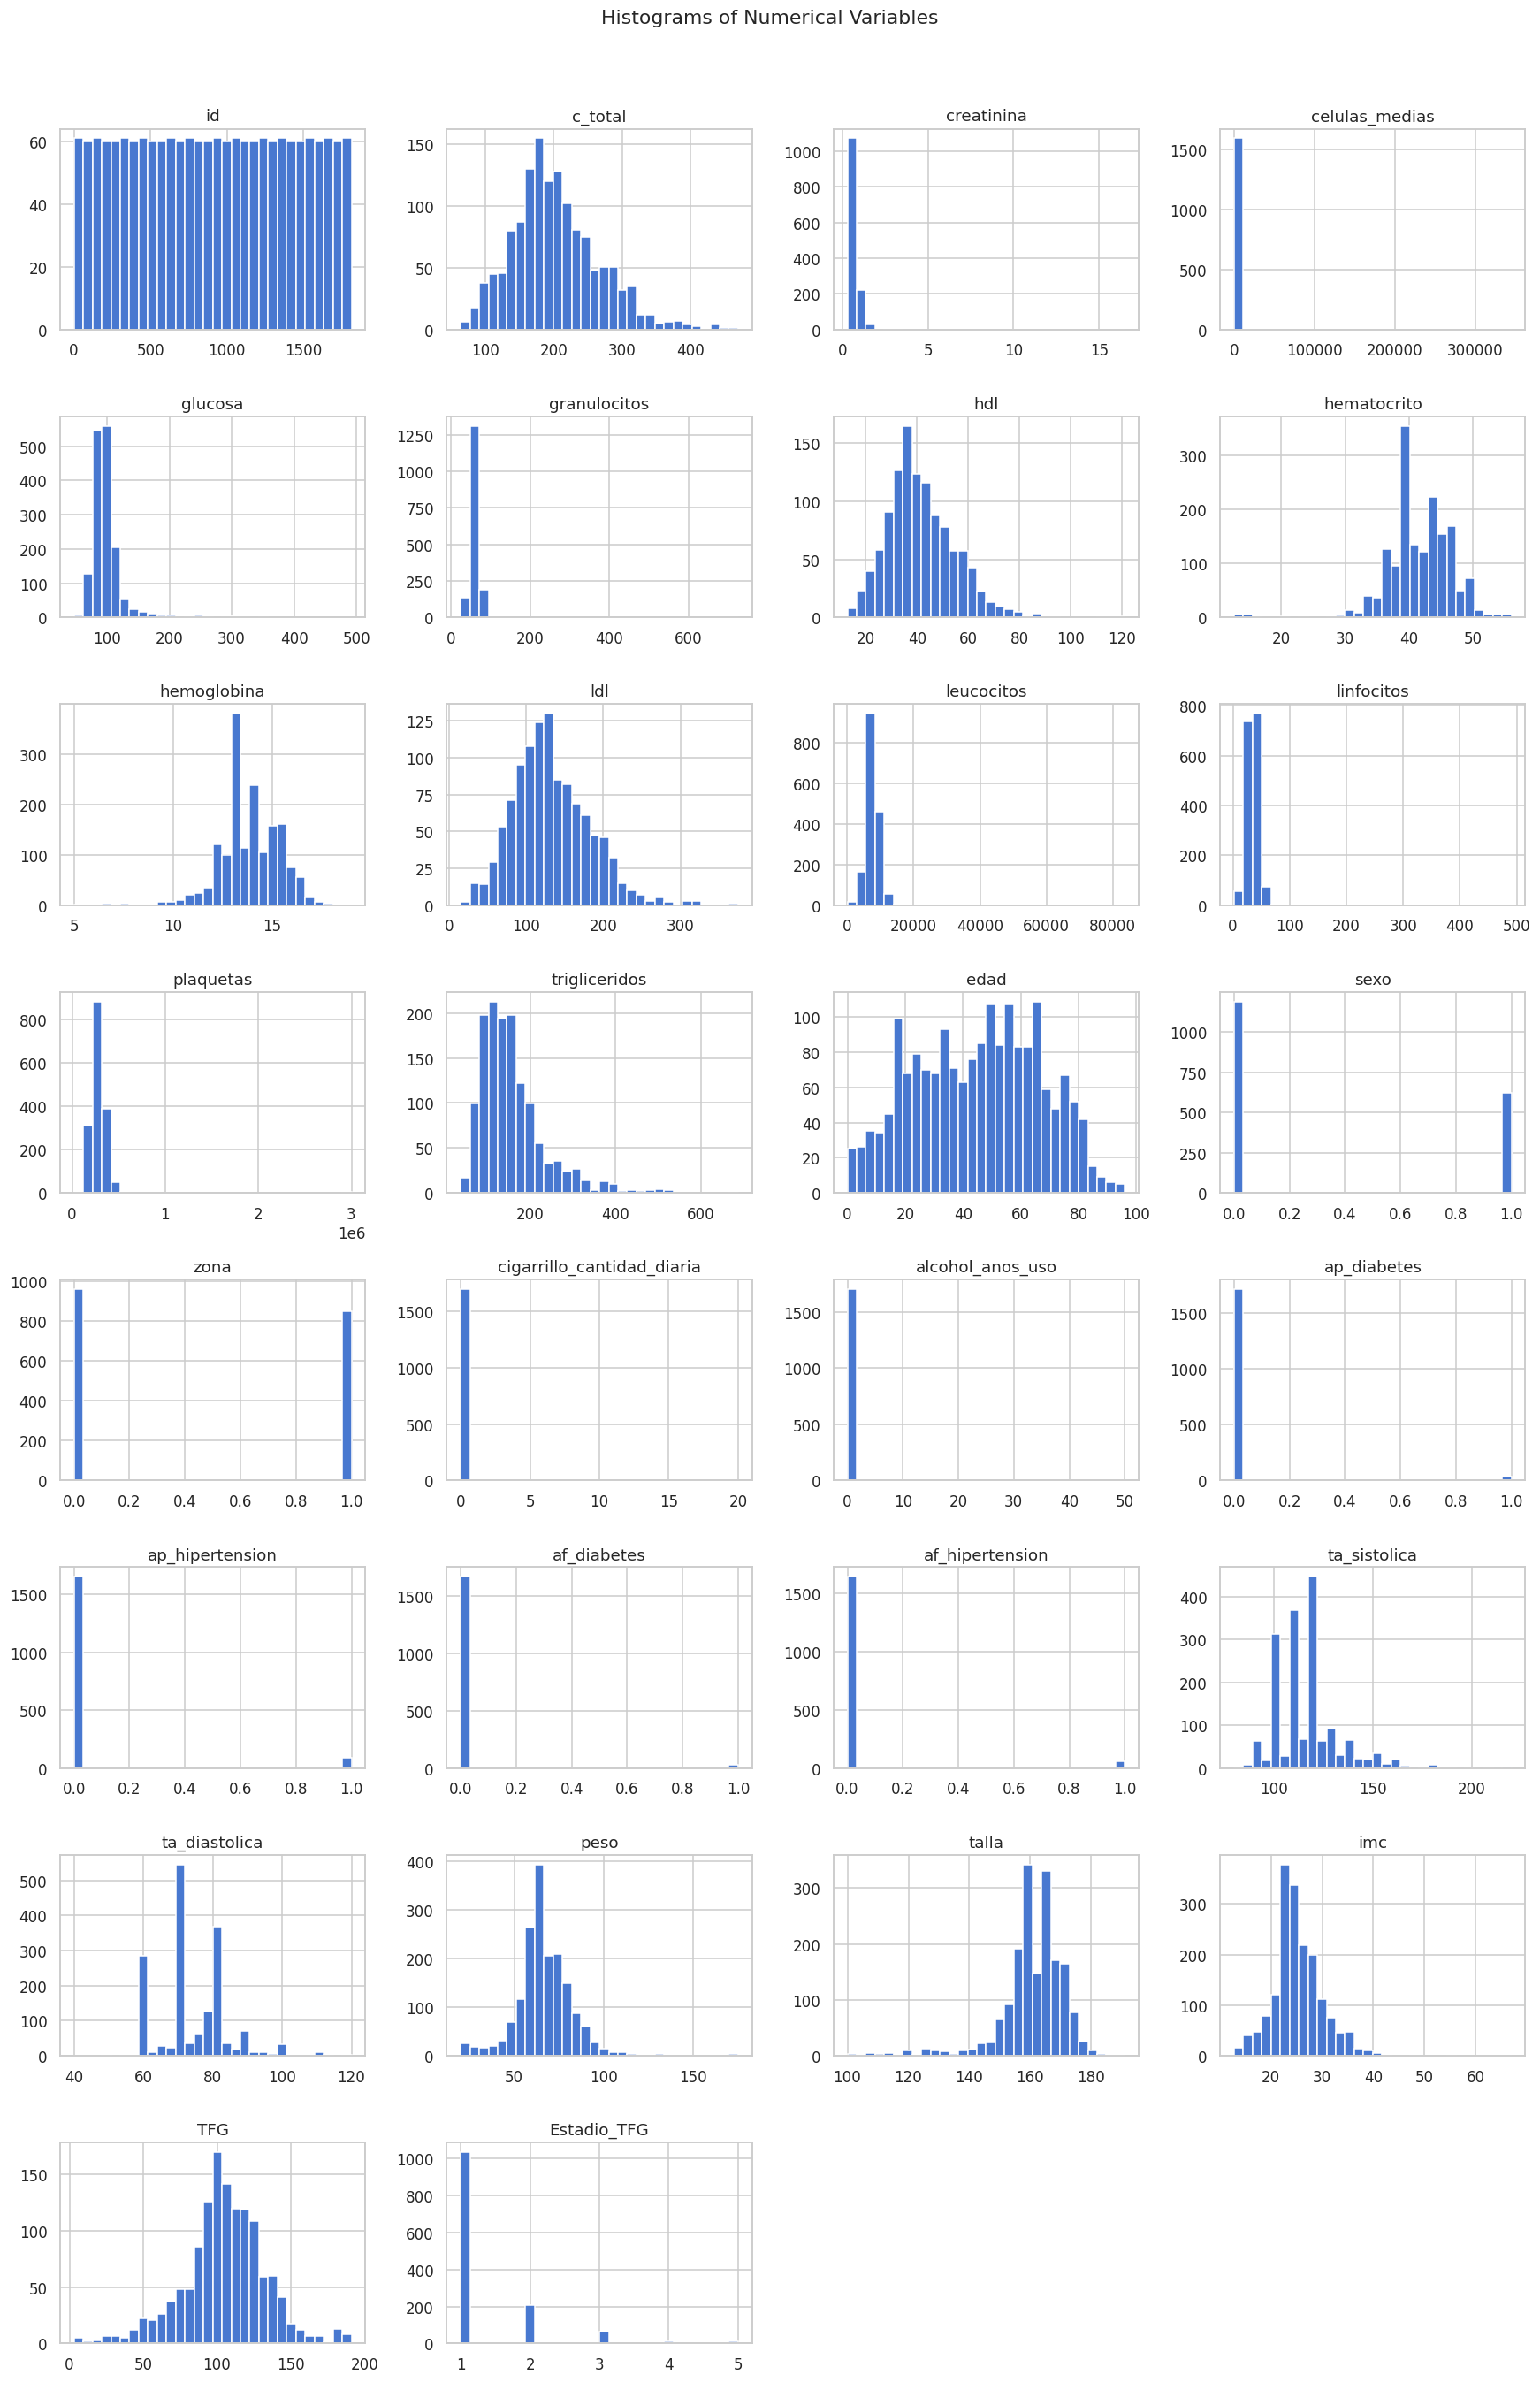

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    num_plots = len(numerical_cols)
    num_cols = 4  # Number of columns for the subplot grid
    num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

    df[numerical_cols].hist(bins=30, figsize=(num_cols * 4, num_rows * 3), layout=(num_rows, num_cols))
    plt.suptitle('Histograms of Numerical Variables', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron columnas numéricas para graficar histogramas.")

3.4.2. BoxPlots

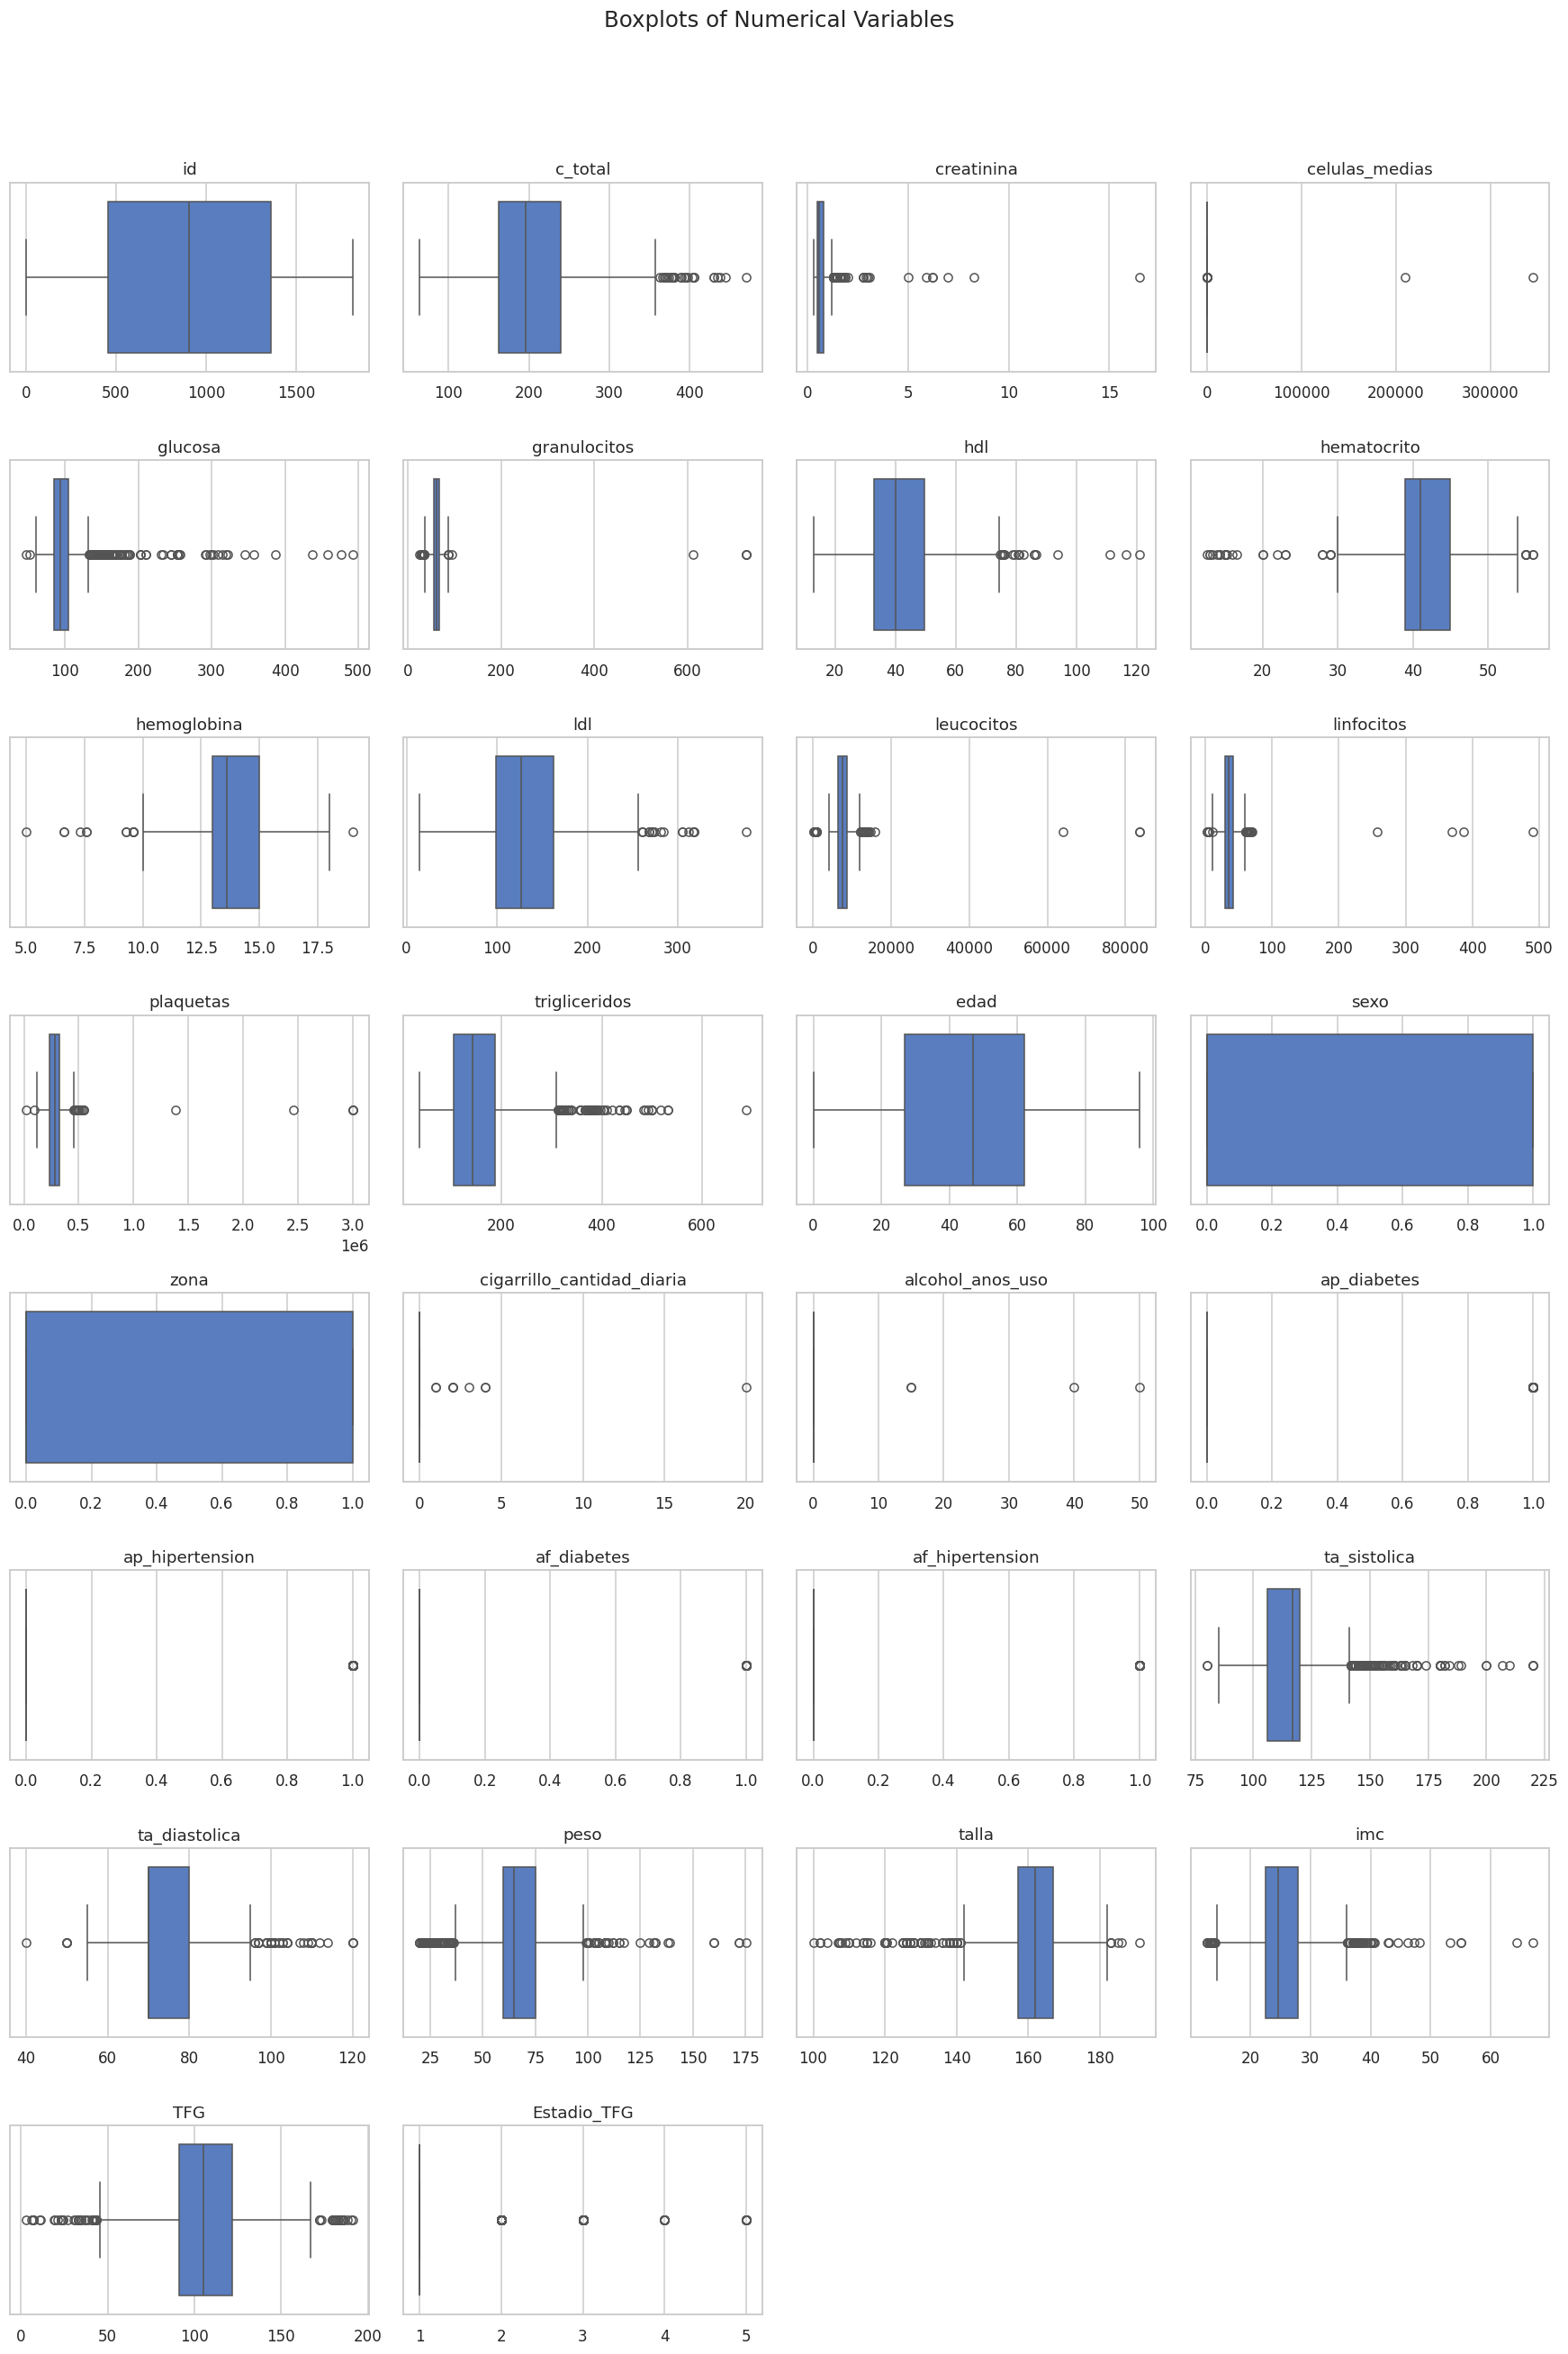

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    num_plots = len(numerical_cols)
    num_cols = 4 # Number of columns for the subplot grid
    num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

    plt.figure(figsize=(num_cols * 4, num_rows * 3))
    plt.suptitle('Boxplots of Numerical Variables', y=1.02, fontsize=16)

    for i, col in enumerate(numerical_cols):
        plt.subplot(num_rows, num_cols, i + 1)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.xlabel('')
        plt.ylabel('')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
else:
    print("No numerical columns found to plot boxplots.")

3.4.3. Diagrama de barras para variables categoricas

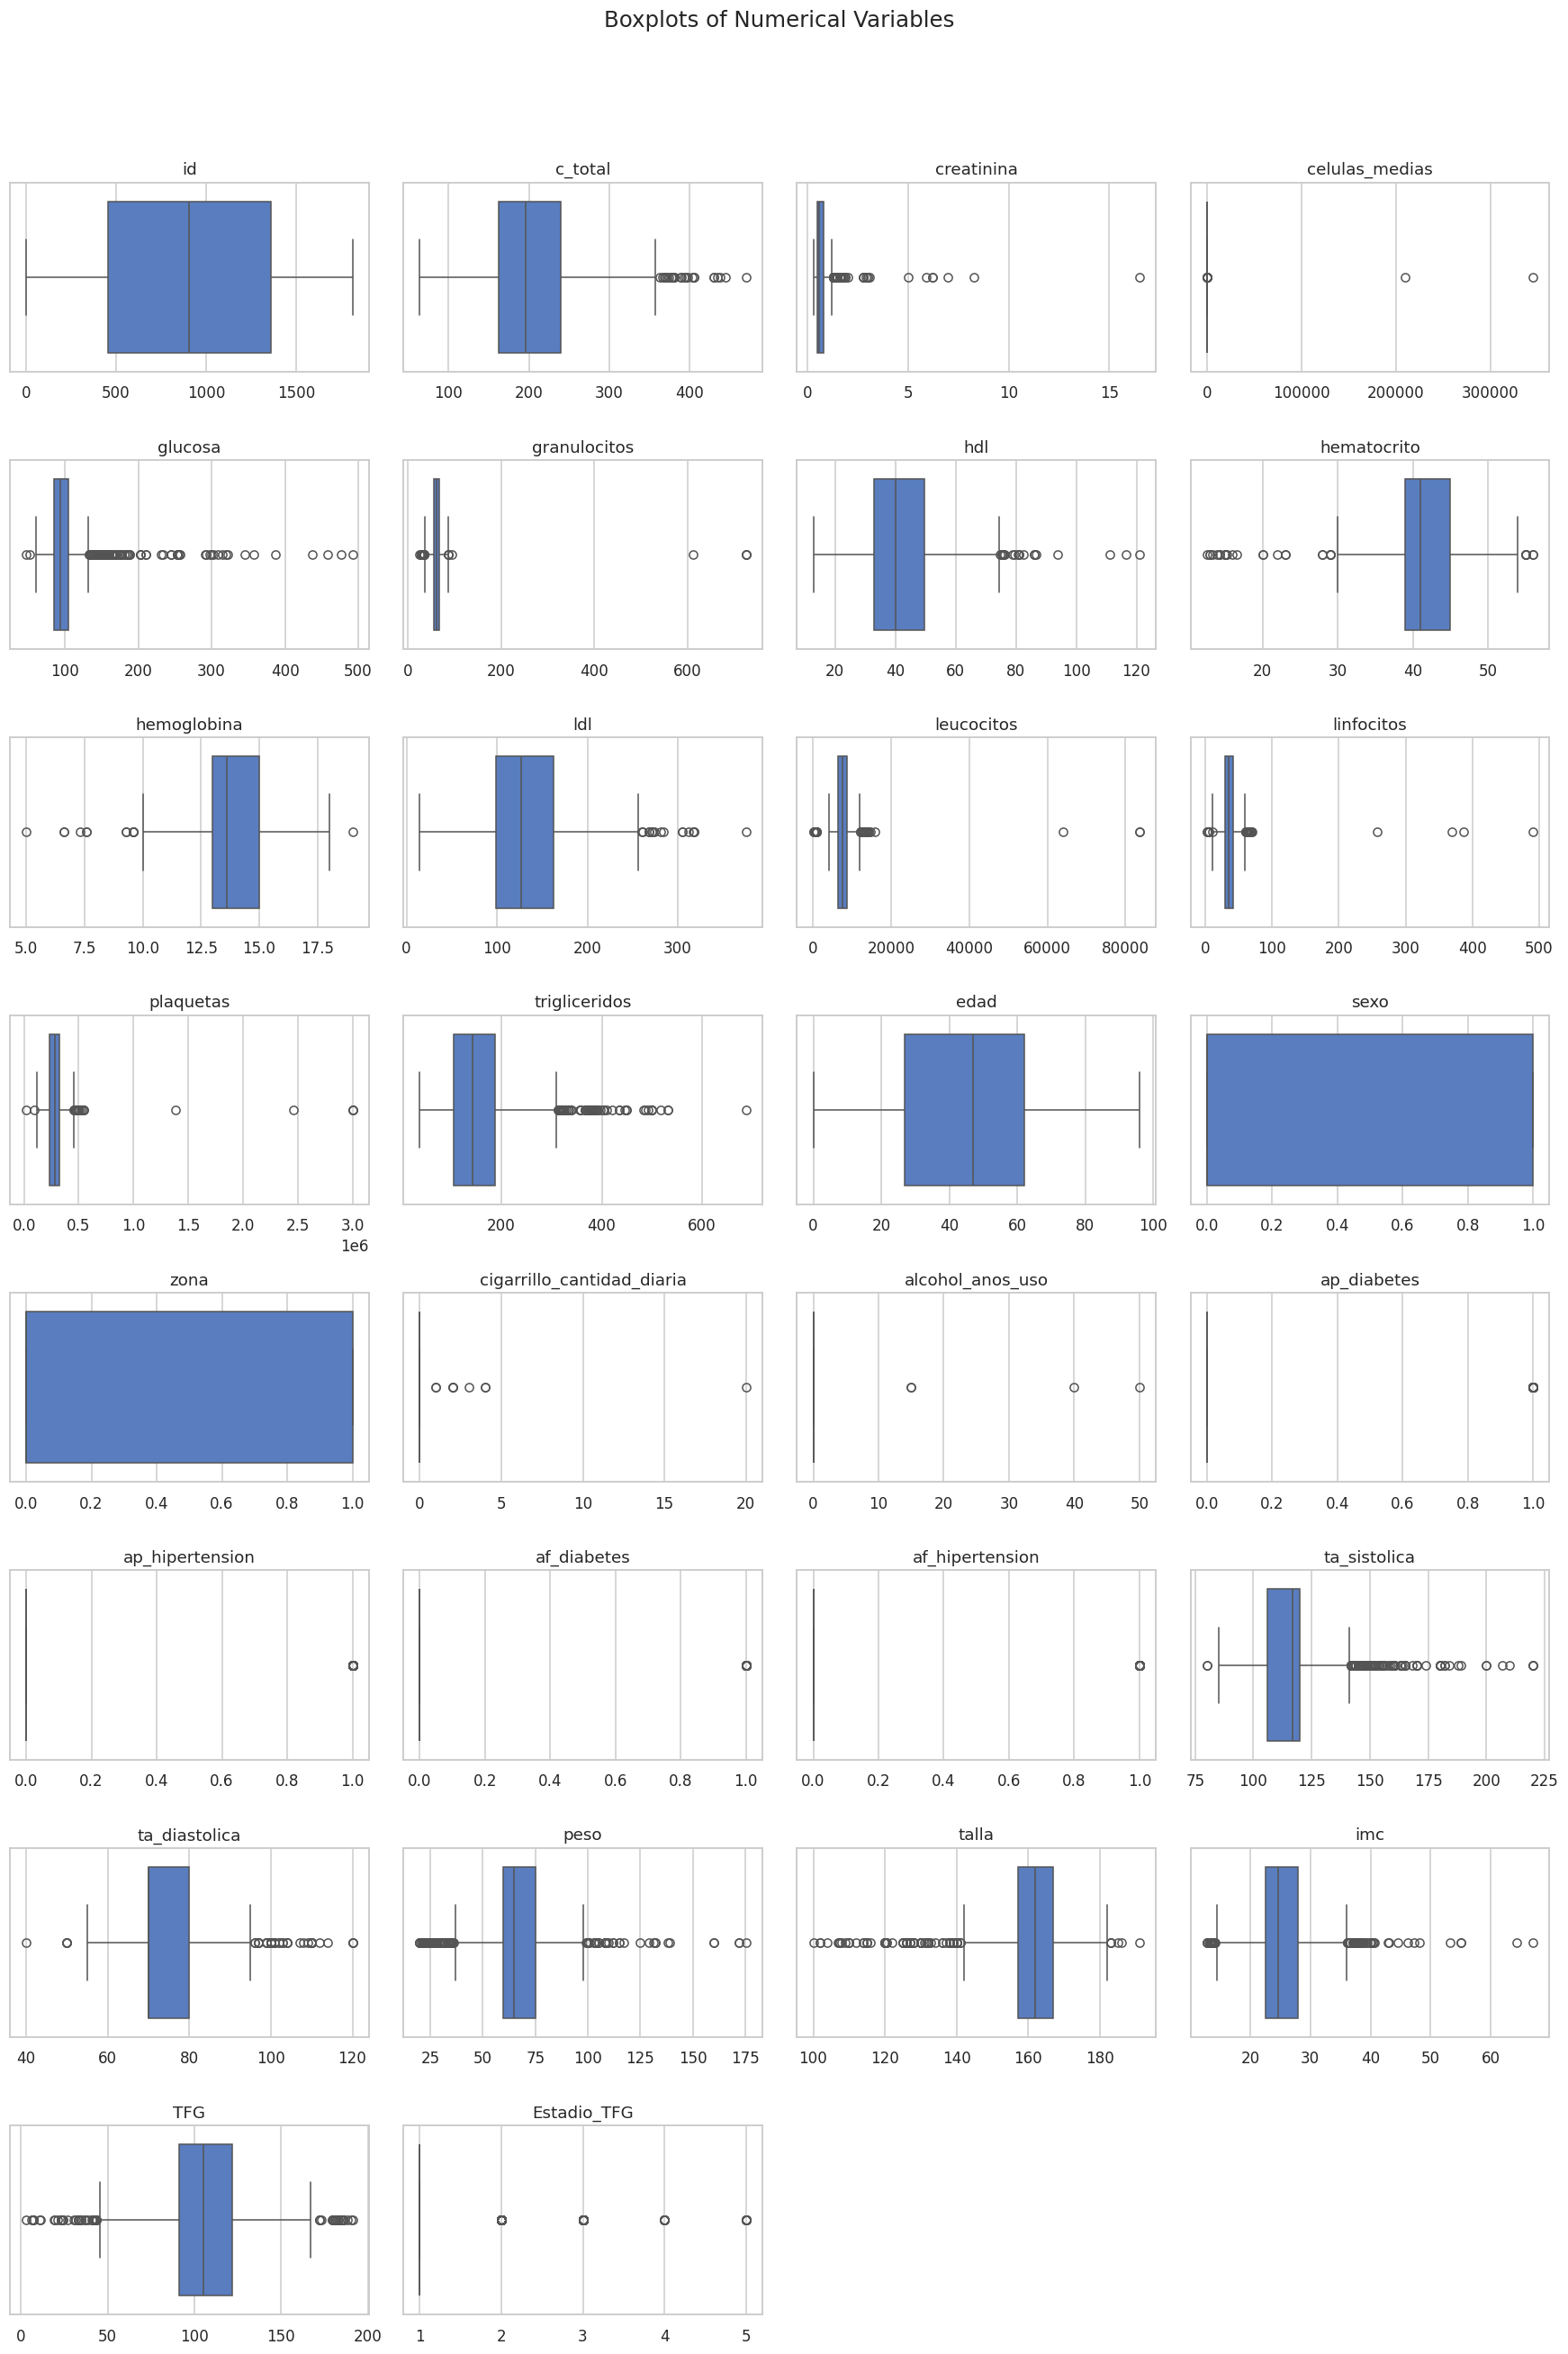

In [11]:
numerical_cols = df.select_dtypes(include=np.number).columns

if not numerical_cols.empty:
    num_plots = len(numerical_cols)
    num_cols = 4 # Number of columns for the subplot grid
    num_rows = (num_plots + num_cols - 1) // num_cols # Calculate rows needed

    plt.figure(figsize=(num_cols * 4, num_rows * 3))
    plt.suptitle('Boxplots of Numerical Variables', y=1.02, fontsize=16)

    for i, col in enumerate(numerical_cols):
        plt.subplot(num_rows, num_cols, i + 1)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.xlabel('')
        plt.ylabel('')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()
else:
    print("No numerical columns found to plot boxplots.")

### Analisis bivariado

En esta etapa se evalúa cómo el comportamiento de una variable puede influir o relacionarse con otra, utilizando herramientas estadísticas y visuales como matrices de correlación, diagramas de dispersión, tablas de contingencia y gráficos comparativos.

Primero se hace la segmentacion de numericas y categoricas, ya que no se pueden aplicar los mismos metodos analiticos para ambos tipos de variables.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Define numerical and categorical variables
vars_num = ['ta_sistolica','ta_diastolica','ldl','hdl','c_total',
            'trigliceridos','glucosa','imc','edad','acido_urico',
            'cigarrillo_cantidad_diaria','alcohol_anos_uso']

vars_cat = ['sexo','ap_diabetes','ap_hipertension','af_diabetes','af_hipertension']

# Filter to ensure these columns actually exist in the DataFrame
vars_num = [v for v in vars_num if v in df.columns]
vars_cat = [v for v in vars_cat if v in df.columns]

# Convert categorical integer columns to object type to ensure proper handling for plotting
for col in vars_cat:
    if col in df.columns:
        df[col] = df[col].astype(object)


print(f"Variables numéricas para el análisis: {', '.join(vars_num)}")
print(f"Variables categóricas para el análisis: {', '.join(vars_cat)}")

Variables numéricas para el análisis: ta_sistolica, ta_diastolica, ldl, hdl, c_total, trigliceridos, glucosa, imc, edad, cigarrillo_cantidad_diaria, alcohol_anos_uso
Variables categóricas para el análisis: sexo, ap_diabetes, ap_hipertension, af_diabetes, af_hipertension


1. Matriz de correlación

En esta matriz se evalúan las variables con mayor potencial de correlación, es decir, aquellas cuyo comportamiento tiende a aumentar o disminuir en conjunto con otra variable. Este análisis permite identificar relaciones lineales entre variables y detectar posibles redundancias dentro del conjunto de datos. Aquí ocurre la primera fase de filtrado de variables para el procesamiento, ya que variables altamente correlacionadas pueden aportar información repetitiva y generar ruido o multicolinealidad en etapas posteriores del análisis y modelado.


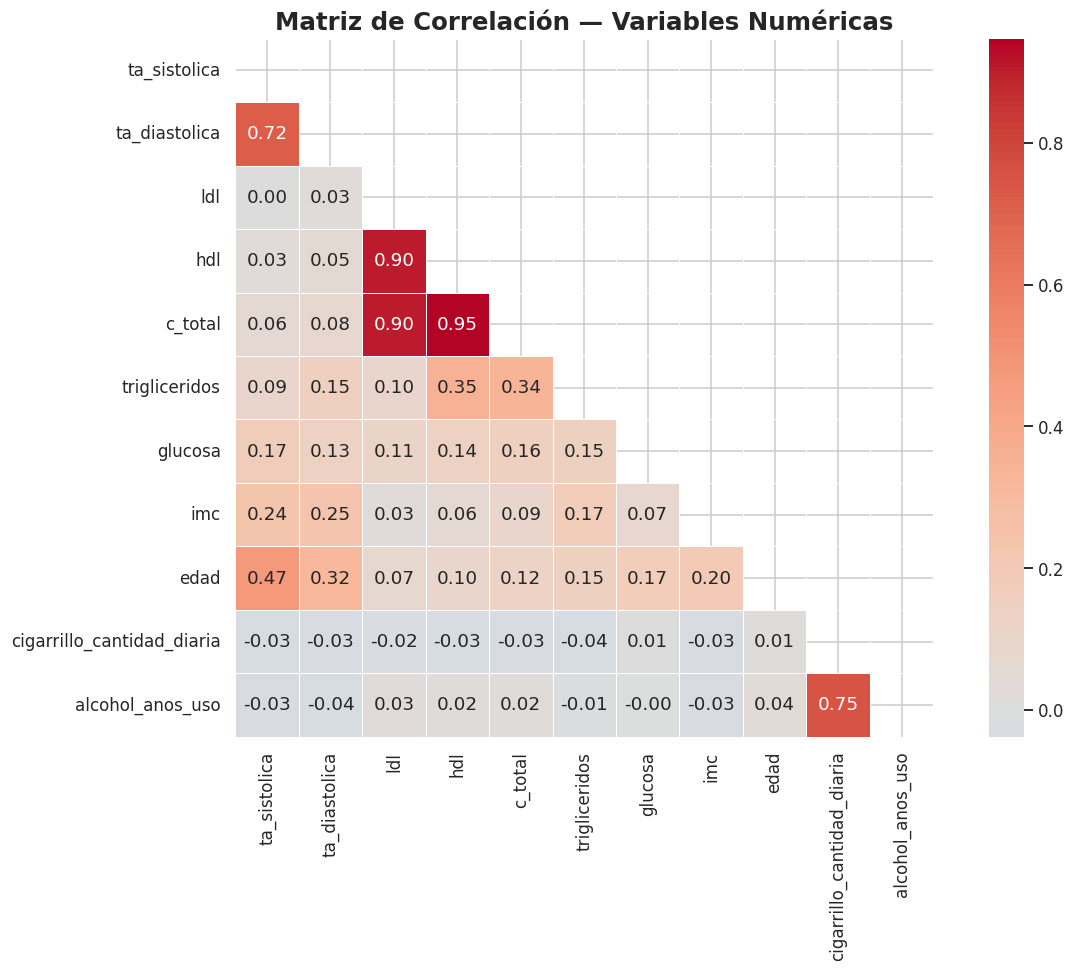

In [13]:
# Calculate correlation matrix for numerical variables
corr = df[vars_num].corr()

# Plotting the heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

A partir de los resultados obtenidos de esta matriz, es posible observar una fuerte correlación entre variabcles de cigarrillo_cantidad_diaria y alcohol_anos_uso, es decir, las personas que desarrollan uno de estos habitos tienen altas probabilidades de desarrollar el otro.

Tambien se observó una fuerte correlación entre variables de c_total, ldl y hdl y esto de debe principalemnte a que la variable c_total contiene a las otras dos variables

2. Coeficientes de correlación de pearson y p-values

In [14]:
# Calculate Pearson correlation and p-values for all pairs of numerical variables
pearson_results = []
for v1, v2 in combinations(vars_num, 2):
    d = df[[v1, v2]].dropna()
    if len(d) > 1:
        r, p = stats.pearsonr(d[v1], d[v2])
        pearson_results.append({
            'V1': v1,
            'V2': v2,
            'r': round(r,3),
            'p': round(p,5),
            'sig': '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'
        })

df_p = pd.DataFrame(pearson_results).sort_values('r', key=abs, ascending=False)
print("Correlaciones de Pearson significativas (p < 0.05):")
display(df_p[df_p['sig'] != 'ns'])

Correlaciones de Pearson significativas (p < 0.05):


,V1,V2,r,p,sig
27,hdl,c_total,0.947,0.00000,***
20,ldl,c_total,0.904,0.00000,***
19,ldl,hdl,0.902,0.00000,***
54,cigarrillo_cantidad_diaria,alcohol_anos_uso,0.750,0.00000,***
0,ta_sistolica,ta_diastolica,0.716,0.00000,***
7,ta_sistolica,edad,0.469,0.00000,***
28,hdl,trigliceridos,0.354,0.00000,***
34,c_total,trigliceridos,0.339,0.00000,***
16,ta_diastolica,edad,0.316,0.00000,***
15,ta_diastolica,imc,0.246,0.00000,***


Con estos resultados, basicamente justificamos lo que encontramos en la matriz de correlaciones. en est caso, las correlaciones mas fuertes son: ldl, hdl y c_total con hdl y c_total (r = 0.947)
ldl y c_total (r = 0.904)
ldl y hdl (r = 0.902)

3. Scatter Plots- Graficos de dispersión

Aqui se escogen las variables con valores signficativos y realiza visualizaciones aleatorias entre relaciones de variables

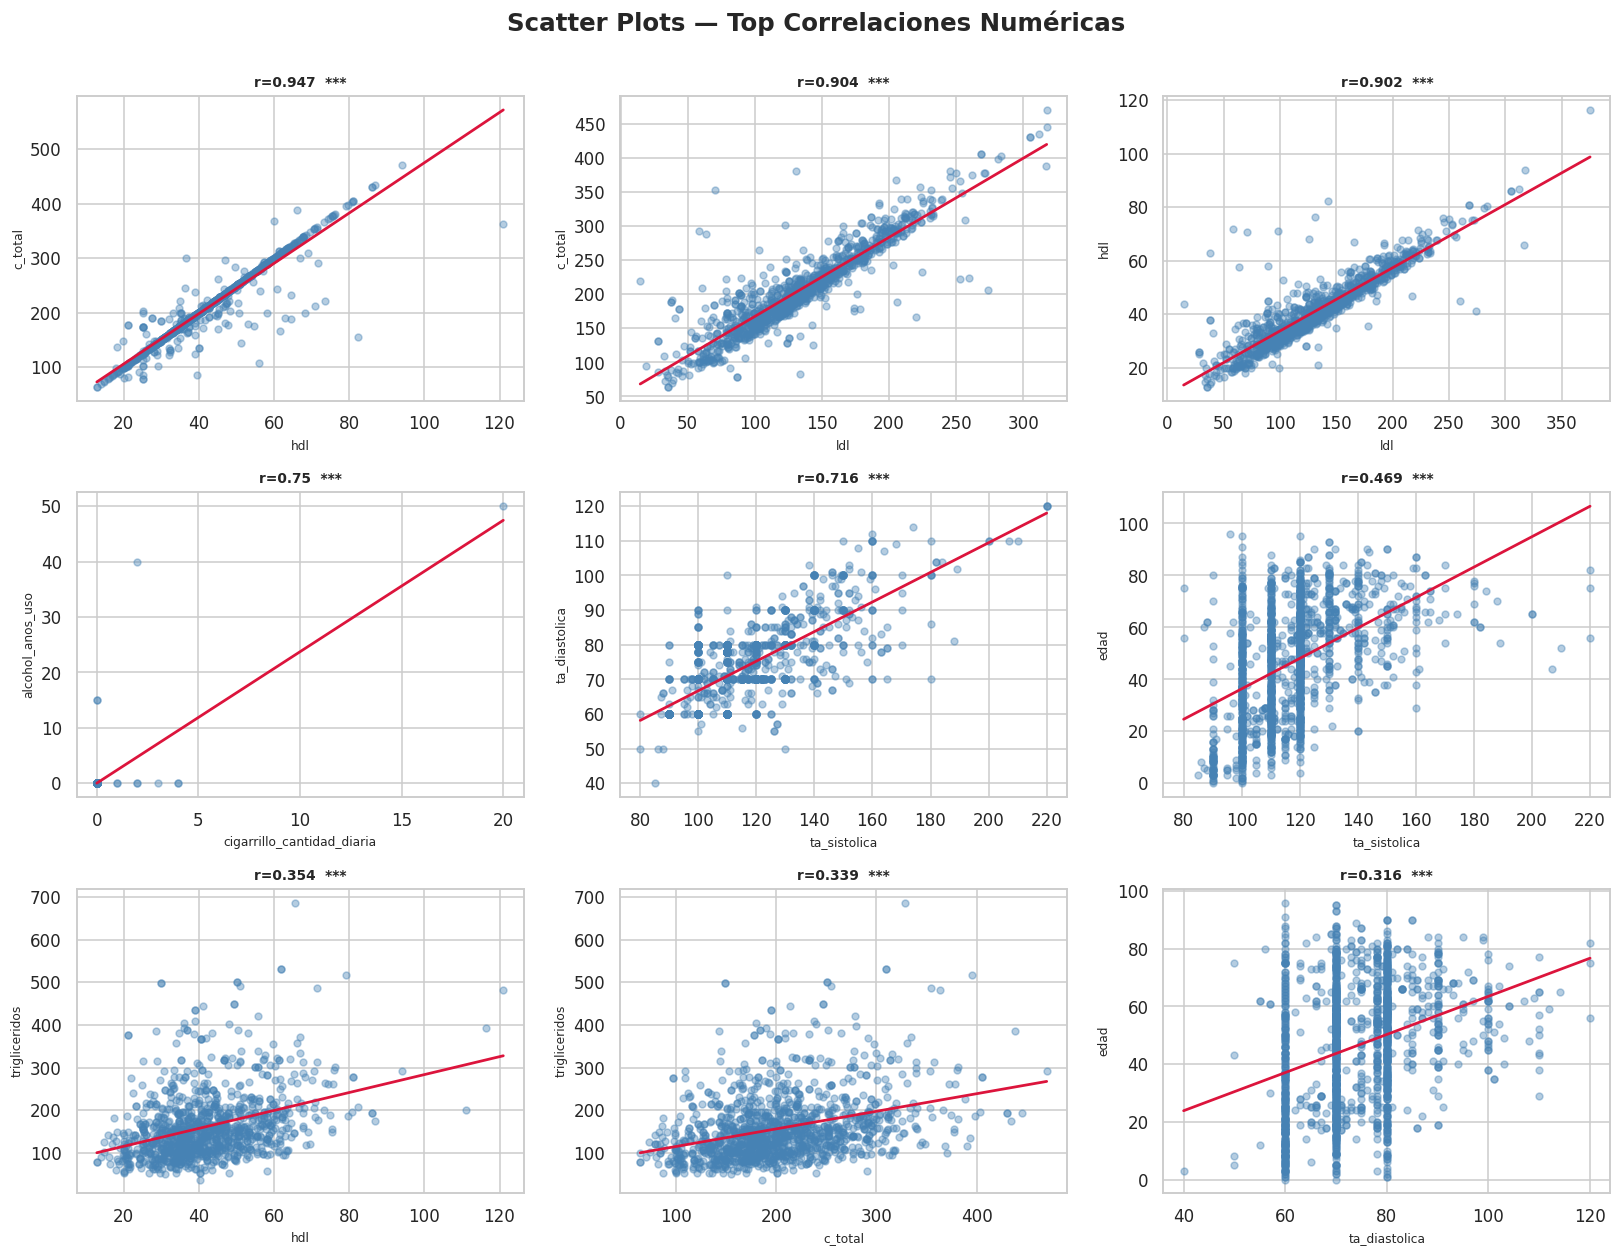

In [15]:
# Select top 9 significant correlations for scatter plots
top_correlations = df_p[df_p['sig'] != 'ns'].head(9)

# Plotting scatter plots
num_plots = len(top_correlations)
if num_plots > 0:
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
    axes = axes.flatten() if num_rows > 1 or num_cols > 1 else [axes]

    for i, (_, row) in enumerate(top_correlations.iterrows()):
        ax = axes[i]
        v1, v2 = row['V1'], row['V2']
        d = df[[v1, v2]].dropna()

        if not d.empty:
            ax.scatter(d[v1], d[v2], alpha=0.4, s=20, color='steelblue')
            # Add a regression line
            m, b = np.polyfit(d[v1], d[v2], 1)
            x_line = np.linspace(d[v1].min(), d[v1].max(), 100)
            ax.plot(x_line, m*x_line+b, color='crimson', lw=1.8)

            ax.set_xlabel(v1, fontsize=8)
            ax.set_ylabel(v2, fontsize=8)
            ax.set_title(f"r={row['r']}  {row['sig']}", fontsize=9, fontweight='bold')
        else:
            ax.set_visible(False) # Hide empty subplots

    plt.suptitle('Scatter Plots — Top Correlaciones Numéricas', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
    plt.show()
else:
    print("No hay correlaciones significativas para graficar scatter plots.")

Como resultado se obtiene la alta correlacion entre variables del perfil lipidico.

La relación entre cigarrillo_cantidad_diaria y alcohol_anos_uso (r = 0.75) también muestra una tendencia positiva importante, aunque con pocos valores concentrados y presencia de muchos ceros.

En la gráfica entre ta_sistolica y ta_diastolica (r = 0.716), se observa una relación positiva clara y clínicamente esperada: a mayor presión sistólica, mayor presión diastólica.

4. Mann-Whitney U Test y Boxplots para variables categóricas vs numéricas

Resultados del test de Mann-Whitney U (p < 0.05):


,cat,num,p,sig
8,sexo,edad,0.00000,***
22,ap_hipertension,ta_sistolica,0.00000,***
19,ap_diabetes,edad,0.00000,***
17,ap_diabetes,glucosa,0.00000,***
30,ap_hipertension,edad,0.00000,***
23,ap_hipertension,ta_diastolica,0.00033,***
34,af_diabetes,ta_diastolica,0.00142,**
0,sexo,ta_sistolica,0.00146,**
6,sexo,glucosa,0.00191,**
2,sexo,ldl,0.00369,**


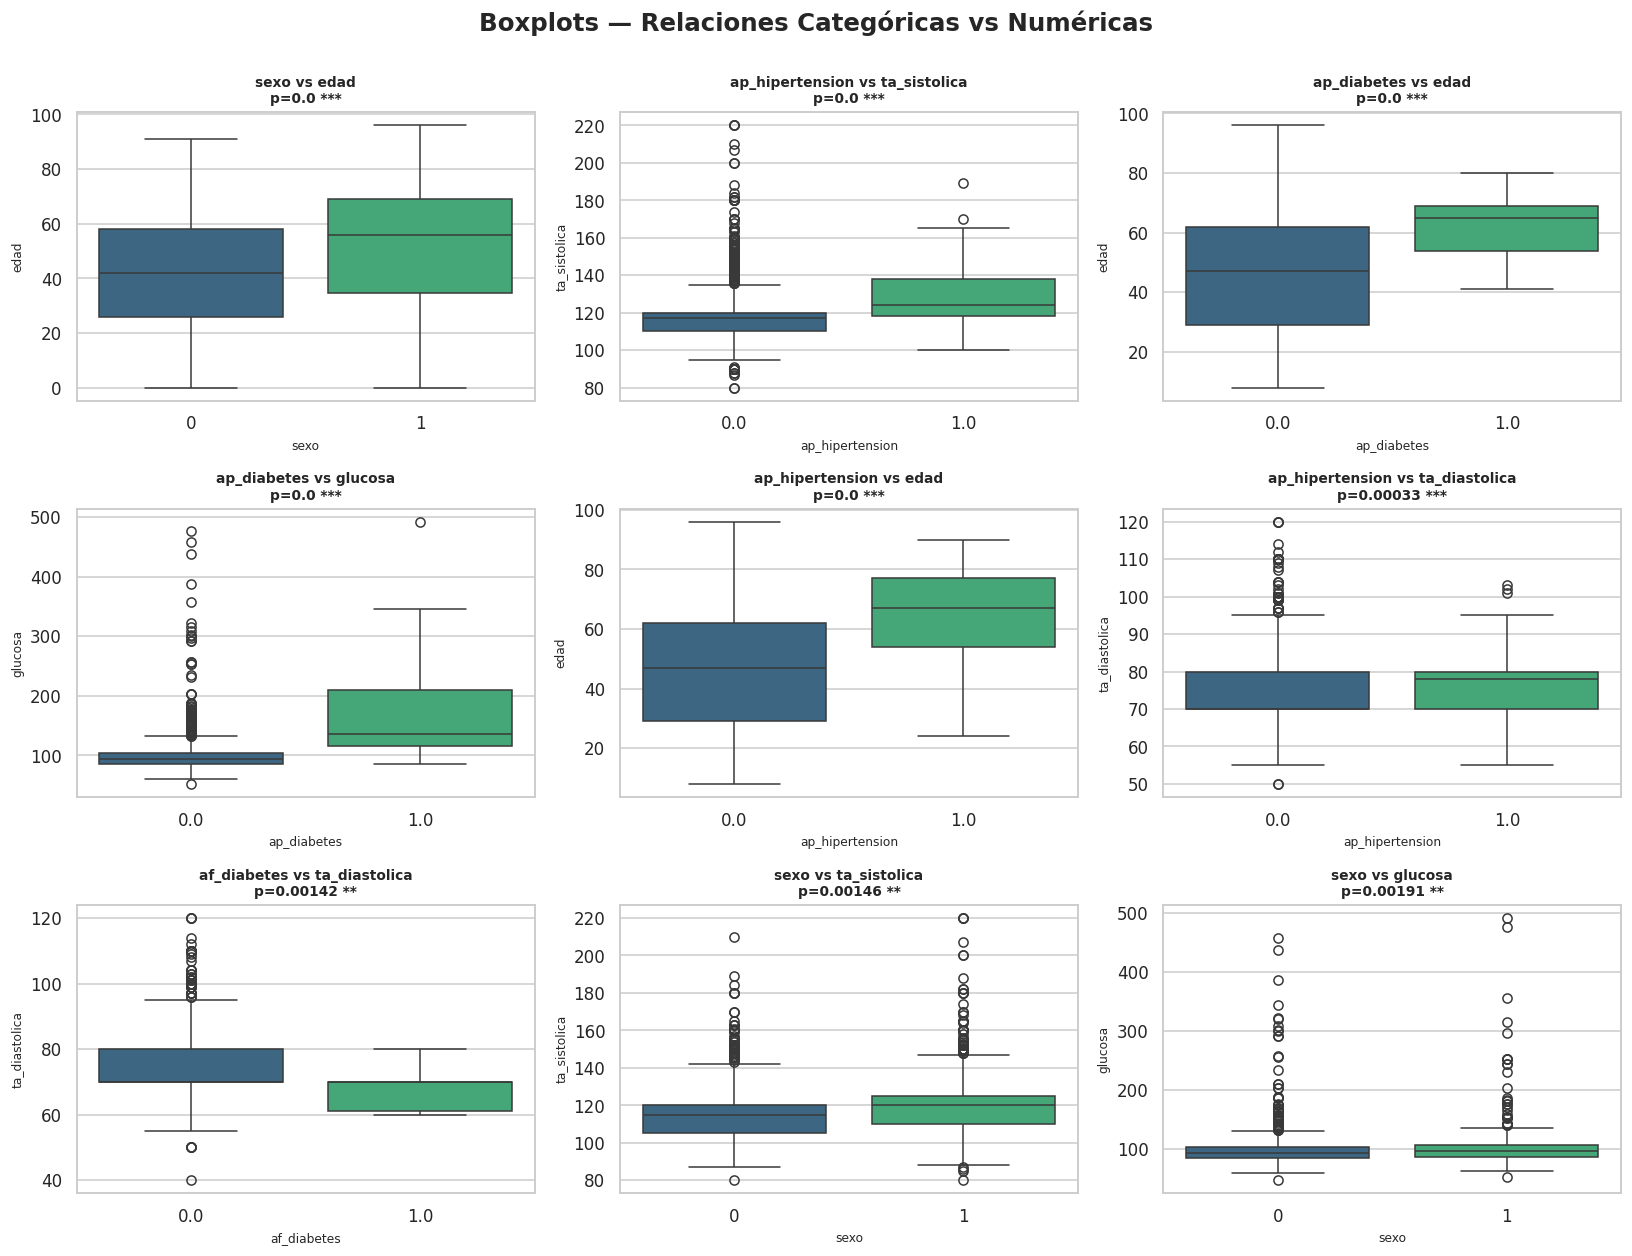

In [16]:
# Perform Mann-Whitney U test and prepare for boxplots
mann_whitney_results = []
for cat_col in vars_cat:
    for num_col in vars_num:
        # Ensure the categorical column is treated as object for grouping
        d = df[[cat_col, num_col]].dropna()

        # Filter to binary categorical variables
        unique_categories = d[cat_col].unique()
        if len(unique_categories) == 2:
            group0 = d[d[cat_col] == unique_categories[0]][num_col]
            group1 = d[d[cat_col] == unique_categories[1]][num_col]

            if len(group0) > 0 and len(group1) > 0: # Ensure both groups have data
                stat, p = stats.mannwhitneyu(group0, group1, alternative='two-sided')
                mann_whitney_results.append({
                    'cat': cat_col,
                    'num': num_col,
                    'p': round(p,5),
                    'sig': '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'ns'
                })

df_t = pd.DataFrame(mann_whitney_results).sort_values('p')
print("Resultados del test de Mann-Whitney U (p < 0.05):")
display(df_t[df_t['sig'] != 'ns'])

# Select top 9 significant relationships for boxplots
top_boxplots = df_t[df_t['sig'] != 'ns'].head(9)

# Plotting boxplots
num_plots = len(top_boxplots)
if num_plots > 0:
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
    axes = axes.flatten() if num_rows > 1 or num_cols > 1 else [axes]

    for i, (_, row) in enumerate(top_boxplots.iterrows()):
        ax = axes[i]
        cat_col, num_col = row['cat'], row['num']
        d = df[[cat_col, num_col]].dropna()

        if not d.empty:
            sns.boxplot(x=cat_col, y=num_col, data=d, ax=ax, palette='viridis')
            ax.set_title(f"{cat_col} vs {num_col}\np={row['p']} {row['sig']}", fontsize=9, fontweight='bold')
            ax.set_xlabel(cat_col, fontsize=8)
            ax.set_ylabel(num_col, fontsize=8)
        else:
            ax.set_visible(False) # Hide empty subplots

    plt.suptitle('Boxplots — Relaciones Categóricas vs Numéricas', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
    plt.show()
else:
    print("No hay relaciones significativas (categórica vs numérica) para graficar boxplots.")

Perfil lipídico ldl, hdl y c_total están fuertemente correlacionadas entre sí (r > 0.75). Para el clustering usa solo ldl y hdl para evitar redundancia con c_total Perfil conductual cigarrillo_cantidad_diaria y alcohol_anos_uso van juntas (r = 0.75). Representan un perfil de riesgo conductual combinado, incluye ambas. Diabetes ap_diabetes separa muy bien la glucosa entre grupos (p = 0.0). Son consistentes y complementarias, incluye las dos. Hipertensión y edad ap_hipertension y edad muestran diferencias claras entre grupos. Los hipertensos son significativamente mayores. Ambas son relevantes para el clustering. Sexo Diferencia significativamente el acido_urico y la edad. Incluirlo como variable de ajuste.

## Pre-procesamiento

Esta sección consta de varias etapas de preprocesamiento orientadas a optimizar la calidad del conjunto de datos antes del modelado. Entre ellas se incluyen una segunda limpieza más profunda, la winsorización de valores extremos, la imputación de datos faltantes y la estandarización de variables numéricas. El objetivo principal es reducir el impacto del ruido, los outliers y las inconsistencias presentes en la información, dejando la data en condiciones óptimas para ser procesada por algoritmos de análisis, clustering o aprendizaje automático.


### 1. Revisión preliminar de datos nulos para escoger el metodo de imputación

In [17]:
import pandas as pd

df = pd.read_csv("datos_limpios.csv", sep=';')

pct_nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(pct_nulos[pct_nulos > 0].round(1))

ldl                           38.7
hdl                           37.2
Estadio_TFG                   26.7
creatinina                    26.2
TFG                           26.0
trigliceridos                 24.4
c_total                       23.7
glucosa                       12.7
celulas_medias                12.1
hemoglobina                    9.7
plaquetas                      9.5
linfocitos                     9.4
leucocitos                     9.4
granulocitos                   9.4
hematocrito                    8.8
af_diabetes                    6.4
af_hipertension                6.4
ta_sistolica                   6.0
alcohol_anos_uso               5.9
cigarrillo_cantidad_diaria     5.9
ta_diastolica                  5.8
peso                           4.0
ap_diabetes                    3.9
ap_hipertension                3.9
talla                          3.2
imc                            3.0
dtype: float64


La mayor concentración de datos nulos se encuentra en las variables del perfil lipidico, metabolico y renal, superando un 20% de datos faltantes que llegan hasta el  38.7%

### 2. Limpieza #2

Antes de imputar, se eliminan las variables que basados en las correlaciones y en un analisis del panorama general, decidimos que no pasaran a fases posteriores.

In [18]:
# Eliminación de variables

# Se elimina 'id' porque no es una variable predictora
df = df.drop(columns=['id'])
print("Columna 'id' eliminada.")

# Eliminación de variables seleccionadas por baja variabilidad y redundancia medica
df = df.drop(columns=[
    'cigarrillo_cantidad_diaria',
    'alcohol_anos_uso',
    'ap_diabetes',
    'af_hipertension',
    'af_diabetes',
    'hematocrito',
    'granulocitos',
    'celulas_medias',
    'linfocitos'
], errors='ignore')

print("Columnas eliminadas del DataFrame.")

# Eliminación de variable derivada
df = df.drop(columns=['Estadio_TFG'], errors='ignore')
print("Columna 'Estadio_TFG' eliminada.")

Columna 'id' eliminada.
Columnas eliminadas del DataFrame.
Columna 'Estadio_TFG' eliminada.


### 3. Imputación de datos faltantes

Debido a que la cantidad de datos no supera el 40% no se elimina ninguna variable, y se opta por usar el metodo del KNN, KNN (K-Nearest Neighbors) para imputación significa que para rellenar un valor nulo, busca los K pacientes más similares (por las otras variables) y usa el promedio de sus valores.

Esto evita alterar la naturalidad clinica, mejorando la representatividad de todas las variables.

In [19]:
from sklearn.impute import KNNImputer
#  1. KNN imputación
# KNNImputer solo trabaja con numéricas
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

imputer = KNNImputer(n_neighbors=5)
df[cols_numericas] = imputer.fit_transform(df[cols_numericas])

print("\n Imputación KNN completada")
print(f"Nulos restantes: {df.isnull().sum().sum()}")


 Imputación KNN completada
Nulos restantes: 0


### 4. Winsorización

En este caso, la winsorización no se hizo pro defecto, sino que se usó un modelo hibrido ahciendo recortes con sentido clinico.

In [20]:
def winsorizar_expert(df_input):
    df = df_input.copy()

    limites_expertos = {
        'c_total':       (0,     550.0),
        'creatinina':    (0,     2.0),
        'celulas_medias':(0,     20.0),
        'glucosa':       (25.0,  492.0),
        'hdl':           (0,     120.0),
        'hematocrito':   (14.0,  63.0),
        'hemoglobina':   (7.0,   21.0),
        'ldl':           (0,     404.6),
        'trigliceridos': (0,     420.0),
        'edad':          (6,     110),
        'ta_sistolica':  (60.5,  220.0),
        'ta_diastolica': (40.0,  120.0),
        'peso':          (9.0,   170.0),
        'talla':         (1.27,  1.97),
        'imc':           (4.51,  60.0),
        'TFG':           (11.47, 197.39)
    }

    for var, (l_inf, l_sup) in limites_expertos.items():
        if var in df.columns:
            df[var] = df[var].clip(lower=l_inf, upper=l_sup)

    return df


 # Aplicamos la winsorización con los límites definidos por expertos
df = winsorizar_expert(df)
print("Winsorización aplicada al DataFrame.")

Winsorización aplicada al DataFrame.


### 5. Exclusión var clusters

Se eliminan variables poco representativas para los clusters

In [21]:
# Variables a excluir del clustering por baja representatividad o irrelevancia
cols_excluir = [
    'acido_urico',
    'cigarrillo_cantidad_diaria',
    'ap_diabetes',
    'alcohol_anos_uso',
    'af_diabetes',
    'af_hipertension'
]

# Crear DataFrame limpio para el modelo (sin modificar df original)
df_modelo = df.drop(columns=cols_excluir, errors='ignore')

print(f"Columnas eliminadas: {cols_excluir}")
print(f"Columnas restantes para el K-Means ({len(df_modelo.columns)}):")
print(list(df_modelo.columns))

Columnas eliminadas: ['acido_urico', 'cigarrillo_cantidad_diaria', 'ap_diabetes', 'alcohol_anos_uso', 'af_diabetes', 'af_hipertension']
Columnas restantes para el K-Means (19):
['c_total', 'creatinina', 'glucosa', 'hdl', 'hemoglobina', 'ldl', 'leucocitos', 'plaquetas', 'trigliceridos', 'edad', 'sexo', 'zona', 'ap_hipertension', 'ta_sistolica', 'ta_diastolica', 'peso', 'talla', 'imc', 'TFG']


## División train/test

En esta sección se realiza la división de la data de entranmiento y de evaluación utilizando el metodo 80/20

In [22]:
from sklearn.model_selection import train_test_split

# Para clustering, usamos df_modelo que ya tiene excluidas las variables de baja representatividad.
# 'X' usa df_modelo (sin las variables excluidas) para el clustering.
X = df_modelo.copy()

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} filas, {X_train.shape[1]} columnas")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} filas, {X_test.shape[1]} columnas")

print(f"\nVariables que entran al K-Means:")
print(list(X_train.columns))

Tamaño del conjunto de entrenamiento: 1450 filas, 19 columnas
Tamaño del conjunto de prueba: 363 filas, 19 columnas

Variables que entran al K-Means:
['c_total', 'creatinina', 'glucosa', 'hdl', 'hemoglobina', 'ldl', 'leucocitos', 'plaquetas', 'trigliceridos', 'edad', 'sexo', 'zona', 'ap_hipertension', 'ta_sistolica', 'ta_diastolica', 'peso', 'talla', 'imc', 'TFG']


## Estandarización

Aplicamos estandarización/normalización para que el modelo no se incline por variables mas grandes numericamente hablando, es decir, se hace una compatibilidad entre las variables evaluadas.

Ahora, se hace estandarizacion con StandardScaler ya que esta usa el emtodo z-score para escalar datos y transformar la media en 0 y la desviacion en 1. Este metodo fue escogido porque es mejor en aplicaicones clinicas

In [23]:
from sklearn.preprocessing import StandardScaler

# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar el scaler a los datos de entrenamiento y transformar los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformar los datos de prueba usando el mismo scaler ajustado
X_test_scaled = scaler.transform(X_test)

# Convertir los arrays escalados de nuevo a DataFrames para mantener las etiquetas de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Datos de entrenamiento estandarizados (primeras 5 filas):")
display(X_train_scaled.head())

print("\nDatos de prueba estandarizados (primeras 5 filas):")
display(X_test_scaled.head())

Datos de entrenamiento estandarizados (primeras 5 filas):


,c_total,creatinina,glucosa,hdl,hemoglobina,ldl,leucocitos,plaquetas,trigliceridos,edad,sexo,zona,ap_hipertension,ta_sistolica,ta_diastolica,peso,talla,imc,TFG
806,1.190247,-0.287366,-0.639745,-0.490973,-1.087712,-1.135798,0.084425,-0.296543,-0.598383,-0.999751,-0.727692,-0.948891,-0.226907,-0.394479,-1.385177,-0.462208,0.0,0.041506,0.606923
1304,-0.492910,-0.067172,-0.454832,-0.507688,-0.203369,-0.351581,-0.270395,0.107396,-0.440577,0.034497,-0.727692,1.053862,-0.226907,-1.002582,-1.385177,0.122997,0.0,0.474674,0.170729
864,-0.054733,-0.213968,0.408097,-0.026278,1.508262,-0.365420,0.307219,-0.204906,0.147607,-0.153548,1.374207,-0.948891,-0.226907,0.213625,0.615307,-0.912366,0.0,-1.197555,0.077328
1747,1.437157,0.446615,-0.578107,1.347747,1.508262,1.405986,-0.187878,0.173256,0.463218,0.598632,1.374207,-0.948891,-0.226907,0.821728,-0.384935,0.245183,0.0,-0.379573,-0.412147
907,0.985069,0.446615,0.932019,0.913141,-0.916549,1.322952,0.527262,-0.591565,-0.770535,1.115755,-0.727692,-0.948891,-0.226907,3.862243,1.215453,-2.069915,0.0,-2.166642,-1.226073



Datos de prueba estandarizados (primeras 5 filas):


,c_total,creatinina,glucosa,hdl,hemoglobina,ldl,leucocitos,plaquetas,trigliceridos,edad,sexo,zona,ap_hipertension,ta_sistolica,ta_diastolica,peso,talla,imc,TFG
990,0.202610,-1.021347,-0.793840,0.160937,-0.631277,0.515670,-0.160373,0.201583,-0.799226,1.397823,-0.727692,-0.948891,-0.226907,-0.394479,-1.385177,-1.304647,0.0,-1.157260,-0.292422
1084,0.341714,1.547586,-0.177462,0.294662,-0.417323,0.580252,0.059670,-0.538453,-0.584037,1.068744,1.374207,-0.948891,-0.226907,-0.394479,-0.384935,-0.076358,0.0,0.023373,-1.457473
1523,-0.127762,0.446615,1.301845,-0.156660,-0.417323,0.063592,0.692295,-0.202073,-0.526653,1.350812,1.374207,-0.948891,-0.226907,-0.394479,-1.085104,-0.397900,0.0,-0.651562,-0.778677
1137,0.133058,-0.287366,-0.269918,0.094074,-0.417323,0.275792,0.664789,-0.088766,-0.325810,0.316564,-0.727692,-0.948891,-0.226907,-0.394479,-0.384935,-0.076358,0.0,-0.280851,-0.190550
1389,0.251296,1.547586,-0.226772,0.135864,-1.843682,-0.161524,-0.215384,-0.100805,1.438743,1.397823,-0.727692,1.053862,4.407101,-0.394479,0.415259,-0.397900,0.0,-0.651562,-2.141521


## Aprendizaje NO-supervisado

### 1. PCA- Analisis de componentes principales

En esta sección se hace una reduccion de dimensionalidad, es decir, reducir las 19 variables a 11 componentes representativos creados por el modelo.

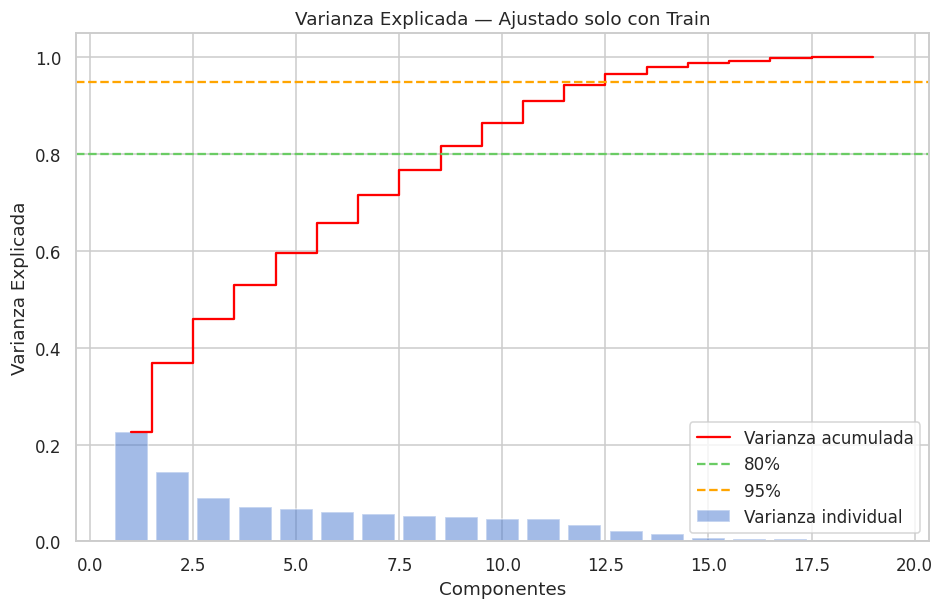

Componentes: 1 | Varianza acumulada: 22.51%
Componentes: 2 | Varianza acumulada: 36.85%
Componentes: 3 | Varianza acumulada: 45.87%
Componentes: 4 | Varianza acumulada: 52.89%
Componentes: 5 | Varianza acumulada: 59.66%
Componentes: 6 | Varianza acumulada: 65.77%
Componentes: 7 | Varianza acumulada: 71.46%
Componentes: 8 | Varianza acumulada: 76.65%
Componentes: 9 | Varianza acumulada: 81.73%
Componentes: 10 | Varianza acumulada: 86.44%
Componentes: 11 | Varianza acumulada: 90.97%
Componentes: 12 | Varianza acumulada: 94.29%
Componentes: 13 | Varianza acumulada: 96.51%
Componentes: 14 | Varianza acumulada: 97.99%
Componentes: 15 | Varianza acumulada: 98.76%
Componentes: 16 | Varianza acumulada: 99.35%
Componentes: 17 | Varianza acumulada: 99.80%
Componentes: 18 | Varianza acumulada: 100.00%
Componentes: 19 | Varianza acumulada: 100.00%


In [24]:
from sklearn.decomposition import PCA

pca_exp = PCA()
pca_exp.fit(X_train_scaled)

varianza_acum = np.cumsum(pca_exp.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca_exp.explained_variance_ratio_) + 1),
        pca_exp.explained_variance_ratio_, alpha=0.5, label='Varianza individual')
plt.step(range(1, len(varianza_acum) + 1), varianza_acum,
         where='mid', color='red', label='Varianza acumulada')
plt.axhline(y=0.80, color='g', linestyle='--', label='80%')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95%')
plt.xlabel('Componentes')
plt.ylabel('Varianza Explicada')
plt.title('Varianza Explicada — Ajustado solo con Train')
plt.legend()
plt.grid(True)
plt.show()

for i, v in enumerate(varianza_acum):
    print(f'Componentes: {i+1} | Varianza acumulada: {v*100:.2f}%')

Aqui encontramos que con 9 componentes se explica una varianza del 81% total de las variables

Selección de componentes

Basado en esto, escogemos la cantidad de componentes mas adecuados a nuestor modelo. En nuestro caso escogemos 11 para una expresion de varianza aproximada al 90%. Esto, se ajusta directamente al Train y al test

In [25]:
N_COMPONENTS = 11  # ajusta según el scree plot

pca_final = PCA(n_components=N_COMPONENTS)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

print(f' PCA ajustado solo con train')
print(f'  Train PCA shape: {X_train_pca.shape}')
print(f'  Test  PCA shape: {X_test_pca.shape}')

 PCA ajustado solo con train
  Train PCA shape: (1450, 11)
  Test  PCA shape: (363, 11)


### 2. K-means

En esta sección aplicamos el metodo de la silueta y el codo para definir la cantidad de cluster que mejor se ajustan a nuestras variables,

2.1. Usando K-means

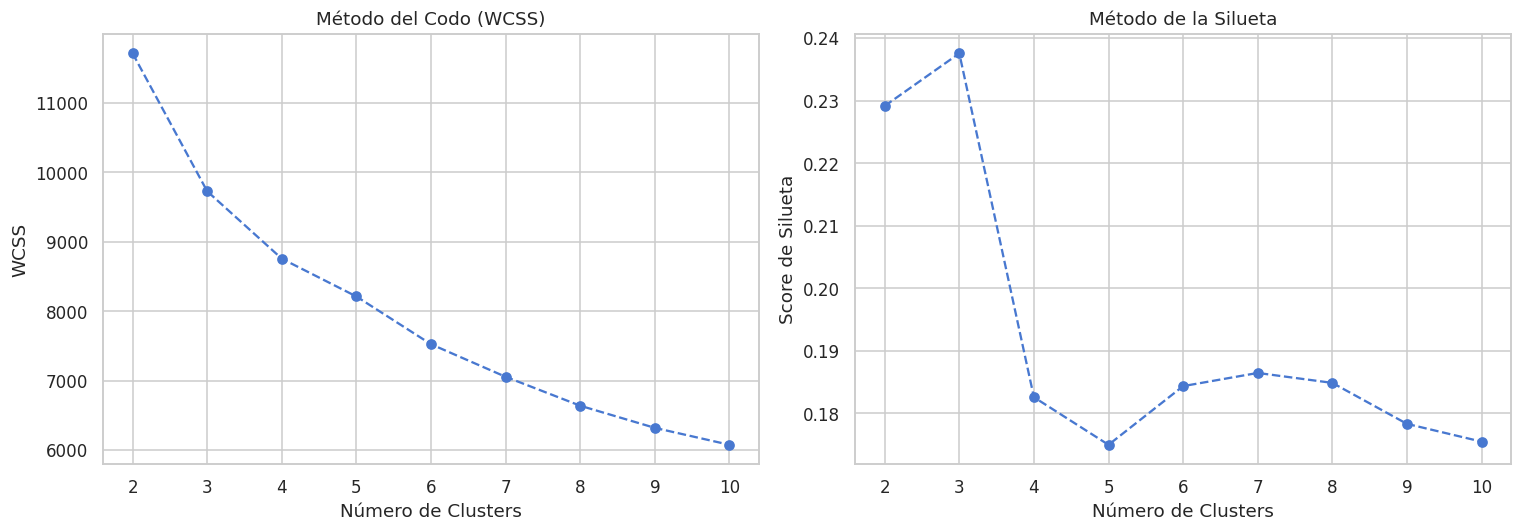

In [26]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

#  1. PCA con 5 componentes
pca = PCA(n_components=5, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

#  2. Listas para métricas
wcss = []
silhouette_scores = []

#  3. Probar diferentes números de clusters
rango_clusters = range(2, 11)  # silueta no funciona con k=1

for i in rango_clusters:
    km = KMeans(n_clusters=i, init='k-means++', random_state=42)
    labels = km.fit_predict(X_train_pca)

    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_pca, labels))

#  4. Gráficas
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

#  Método del codo (WCSS)
ax[0].plot(rango_clusters, wcss, marker='o', linestyle='--')
ax[0].set_title('Método del Codo (WCSS)')
ax[0].set_xlabel('Número de Clusters')
ax[0].set_ylabel('WCSS')
ax[0].grid(True)

# Silueta
ax[1].plot(rango_clusters, silhouette_scores, marker='o', linestyle='--')
ax[1].set_title('Método de la Silueta')
ax[1].set_xlabel('Número de Clusters')
ax[1].set_ylabel('Score de Silueta')
ax[1].grid(True)

plt.tight_layout()
plt.show()

Estas graficas nos indican que k=3 es el mas adecuado. Sin embargo, al hacer una evaluacion anterior de la data, se observaron distribuciones significativas de los grupos por eso se consideró k=4

### 3. Detección de anomalias

En esta sección se aplica un metodo de aprendizaje no supervisado llamado Isolation Forest. Este basicamente, filtra aquellos datos demasiado atipicos que podrian emitir ruido al modelo y aplica unicamente la division de los cluster sobre los datos restantes

In [27]:
# SECCIÓN: DETECCIÓN DE ANOMALÍAS
from sklearn.ensemble import IsolationForest # Import missing class

# Prepare the full dataset for anomaly detection using the fitted scaler and imputer
# df_modelo is already the feature-engineered DataFrame from previous steps
# Aseguramos que X_full_data tenga las mismas columnas que X_train en el momento de fitting del scaler
X_full_data_for_scaling = df[X_train.columns].values

# Apply the same scaler fitted on the training data
X_full_scaled = scaler.transform(X_full_data_for_scaling)

# Como 'df' (y por lo tanto X_full_scaled) no tiene valores nulos después de la limpieza previa,
# un imputer no es estrictamente necesario. Podemos usar X_full_scaled directamente.
X_scaled = X_full_scaled

# Usamos una contaminación del 1% al 2% para capturar esos casos extremos que vimos
iso_forest = IsolationForest(contamination=0.015, random_state=42)
outliers_preds = iso_forest.fit_predict(X_scaled)

# Guardamos quién es anomalía en el DataFrame original antes de separar
df['Es_Anomalia'] = outliers_preds # Aquí se añade la columna al df original

# Creamos el set de datos "limpio" para el modelo de ARTERY
X_limpio_scaled = X_scaled[outliers_preds == 1]
df_limpio = df[df['Es_Anomalia'] == 1].copy() # Asegurarse de que df_limpio se base en el df original con la columna 'Es_Anomalia'

# Guardamos las anomalías para análisis clínico separado
df_alertas_criticas = df[df['Es_Anomalia'] == -1].copy()

print(f"Pacientes con riesgo estándar: {len(df_limpio)}")
print(f"Pacientes con alertas críticas (Anomalías): {len(df_alertas_criticas)}")

# SECCIÓN: CLUSTERING SOBRE DATOS LIMPIOS
kmeans_definitivo = KMeans(n_clusters=4, random_state=42, n_init=10)
df_limpio['Cluster_Final'] = kmeans_definitivo.fit_predict(X_limpio_scaled)

Pacientes con riesgo estándar: 1785
Pacientes con alertas críticas (Anomalías): 28


### 4. Train K-means

Este código realiza el proceso final de clustering utilizando K-Means sobre los datos previamente transformados con PCA, separando correctamente entrenamiento y prueba para evitar fuga de información

In [28]:
# Aplicar a train y test

X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

In [29]:
#Entrenamiento del modelo k_means
kmeans_final = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42
)

# Entrenamiento SOLO con datos de train
kmeans_final.fit(X_train_pca)

KMeans(n_clusters=4, random_state=42)

In [30]:
# Asignación de etiquetas a los clusters

# Clusters asignados al conjunto de entrenamiento
y_train = kmeans_final.labels_

# Predicción de clusters para el conjunto de prueba
y_test = kmeans_final.predict(X_test_pca)

In [31]:
# Distribución de pacientes por clusters

print('K-Means entrenado solo con datos de train')

print(f'\nDistribución en TRAIN:')

for c, n in zip(*np.unique(y_train, return_counts=True)):
    print(f'  Cluster {c}: {n} pacientes ({n/len(y_train)*100:.1f}%)')

print(f'\nDistribución en TEST:')

for c, n in zip(*np.unique(y_test, return_counts=True)):
    print(f'  Cluster {c}: {n} pacientes ({n/len(y_test)*100:.1f}%)')

K-Means entrenado solo con datos de train

Distribución en TRAIN:
  Cluster 0: 360 pacientes (24.8%)
  Cluster 1: 272 pacientes (18.8%)
  Cluster 2: 508 pacientes (35.0%)
  Cluster 3: 310 pacientes (21.4%)

Distribución en TEST:
  Cluster 0: 80 pacientes (22.0%)
  Cluster 1: 67 pacientes (18.5%)
  Cluster 2: 129 pacientes (35.5%)
  Cluster 3: 87 pacientes (24.0%)


A partir de estos resultados, se observa uan distribución semi-balanceada, lo sufucente para continuar con un k=4

### Perfil clinico por cluster

En esta sección se crean clusters por perfiles clinicos caracterizados por una serie de variables.

In [32]:
df_train = X_train.copy()
df_train['Cluster'] = y_train

# Define numerical variables for the profile
variables_numericas = X_train.select_dtypes(include=np.number).columns

perfil = df_train.groupby('Cluster')[variables_numericas].mean().round(2)
print('PERFIL CLÍNICO POR CLUSTER')
print(perfil.T)

PERFIL CLÍNICO POR CLUSTER
Cluster                  0          1          2          3
c_total             276.21     173.69     177.43     182.55
creatinina            0.68       0.47       0.58       1.01
glucosa             107.82      89.85      95.48     106.10
hdl                  56.35      34.11      36.04      36.75
hemoglobina          14.32      13.51      13.64      14.10
ldl                 181.90     111.10     111.66     112.82
leucocitos         7633.37    8355.83    7698.56    7592.81
plaquetas        305161.86  297222.98  289399.74  283571.68
trigliceridos       194.37     111.44     149.32     164.82
edad                 52.56      17.62      41.35      67.48
sexo                  0.33       0.31       0.14       0.74
zona                  0.50       0.48       0.44       0.49
ap_hipertension       0.02       0.00       0.03       0.15
ta_sistolica        119.52     103.74     113.73     128.67
ta_diastolica        76.09      67.00      73.00      78.65
peso         

## Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Se añade el parámetro class_weight='balanced'
# Esto ajustará automáticamente los pesos de forma inversamente proporcional a las frecuencias de las clases.
# ── Parámetros ajustados para reducir overfitting ─────────────
rf = RandomForestClassifier(
    n_estimators=150,        # más árboles = más estabilidad
    max_depth=8,             # más restrictivo que 8
    min_samples_leaf=15,     # cada hoja necesita mínimo 10 obs
    min_samples_split=40,    # mínimo para hacer cualquier split
    max_features="sqrt",     # solo raíz de features por split
    max_samples=0.8,         # cada árbol ve solo 80% del train
    class_weight="balanced", # si tus clusters están desbalanceados
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_pca, y_train)

y_test_pred = rf.predict(X_test_pca)

train_acc = rf.score(X_train_pca, y_train)
test_acc  = rf.score(X_test_pca,  y_test)

print(f'Train: {train_acc:.4f} | Test: {test_acc:.4f} | Gap: {abs(train_acc - test_acc):.4f}')

print(classification_report(
    y_test, y_test_pred,
    target_names=[f'Cluster {i}' for i in range(len(np.unique(y_train)))]
))

Train: 0.9379 | Test: 0.9036 | Gap: 0.0343
              precision    recall  f1-score   support

   Cluster 0       0.88      0.94      0.91        80
   Cluster 1       0.89      0.97      0.93        67
   Cluster 2       0.96      0.81      0.88       129
   Cluster 3       0.87      0.97      0.91        87

    accuracy                           0.90       363
   macro avg       0.90      0.92      0.91       363
weighted avg       0.91      0.90      0.90       363



### Matriz de confusion

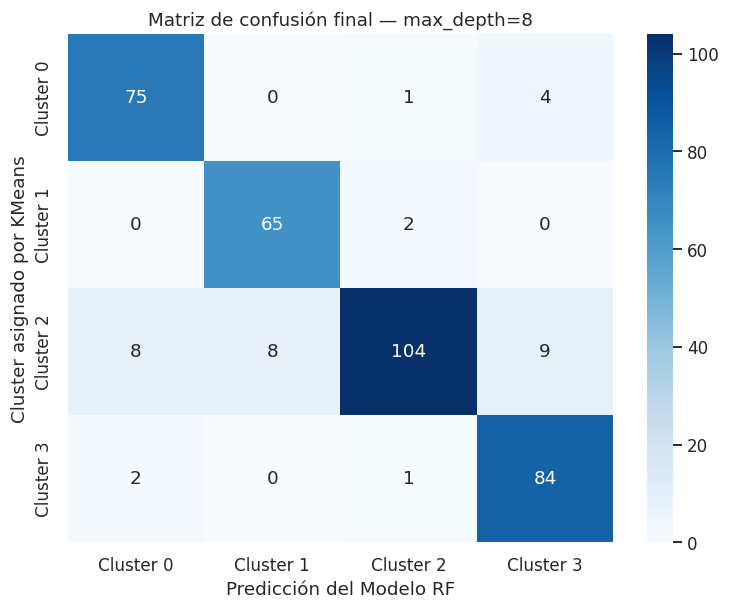

In [34]:
from sklearn.metrics import confusion_matrix

y_test_pred = rf.predict(X_test_pca)

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in range(len(np.unique(y_test)))],
            yticklabels=[f'Cluster {i}' for i in range(len(np.unique(y_test)))])
plt.xlabel('Predicción del Modelo RF')
plt.ylabel('Cluster asignado por KMeans')
plt.title('Matriz de confusión final — max_depth=8')
plt.show()

### Analisis de sensibilidad

In [35]:
for depth in [12, 10, 8, 5]:
    rf_test = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    rf_test.fit(X_train_pca, y_train)
    tr  = rf_test.score(X_train_pca, y_train)
    te  = rf_test.score(X_test_pca,  y_test)
    gap = abs(tr - te)
    print(f'max_depth={str(depth):>4} | Train: {tr:.4f} | Test: {te:.4f} | Gap: {gap:.4f}')

max_depth=  12 | Train: 1.0000 | Test: 0.9477 | Gap: 0.0523
max_depth=  10 | Train: 0.9993 | Test: 0.9449 | Gap: 0.0544
max_depth=   8 | Train: 0.9972 | Test: 0.9394 | Gap: 0.0578
max_depth=   5 | Train: 0.9648 | Test: 0.9174 | Gap: 0.0475


### Validación- Overfitting

In [36]:
# Importación de librerias
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [37]:
# Evalucación de overfitting
train_acc = rf.score(X_train_pca, y_train)
test_acc  = rf.score(X_test_pca, y_test)

gap = abs(train_acc - test_acc)

print('Verificación overfitting')

print(f'Precisión Train: {train_acc:.4f}')
print(f'Precisión Test:  {test_acc:.4f}')
print(f'Gap:             {gap:.4f}  {"OK" if gap < 0.05 else "Revisar"}')

Verificación overfitting
Precisión Train: 0.9379
Precisión Test:  0.9036
Gap:             0.0343  OK


### Validación cruzada

In [38]:
# Validación cruzada

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf,
    X_train_pca,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print('VALIDACIÓN CRUZADA con random forest')

print(f'Puntajes por fold: {cv_scores.round(4)}')
print(f'Media:             {np.mean(cv_scores):.4f}')
print(f'Std:               {np.std(cv_scores):.4f}')

VALIDACIÓN CRUZADA con random forest
Puntajes por fold: [0.9103 0.9138 0.8897 0.9    0.9069]
Media:             0.9041
Std:               0.0086


### Importancia de componentes principales

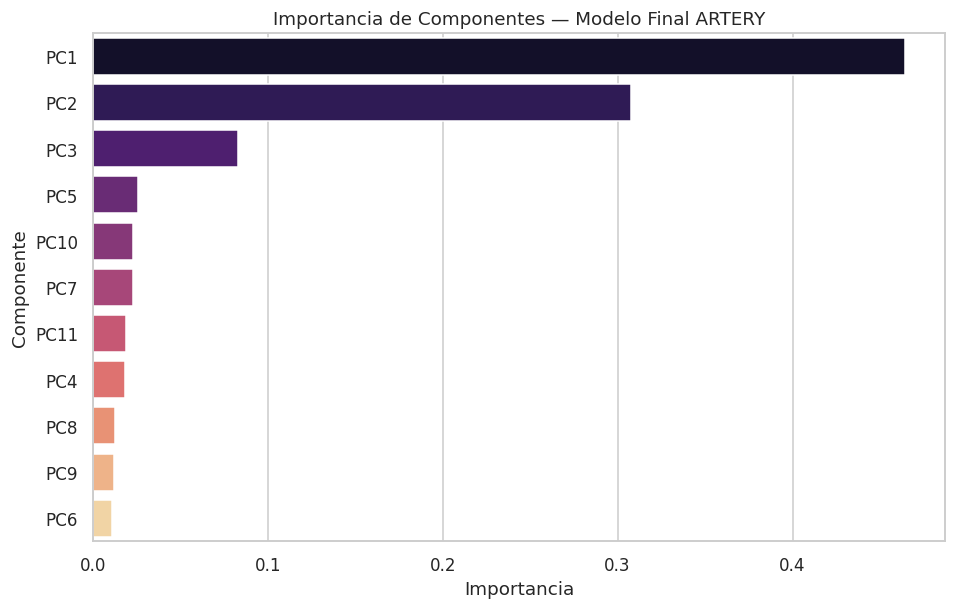

In [39]:
importances = rf.feature_importances_
feature_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
feat_df = pd.DataFrame({'Componente': feature_names, 'Importancia': importances})
feat_df = feat_df.sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Componente', data=feat_df, palette='magma')
plt.title('Importancia de Componentes — Modelo Final ARTERY')
plt.show()

### Clusters de riesgo

1. Por 4 componentes principales

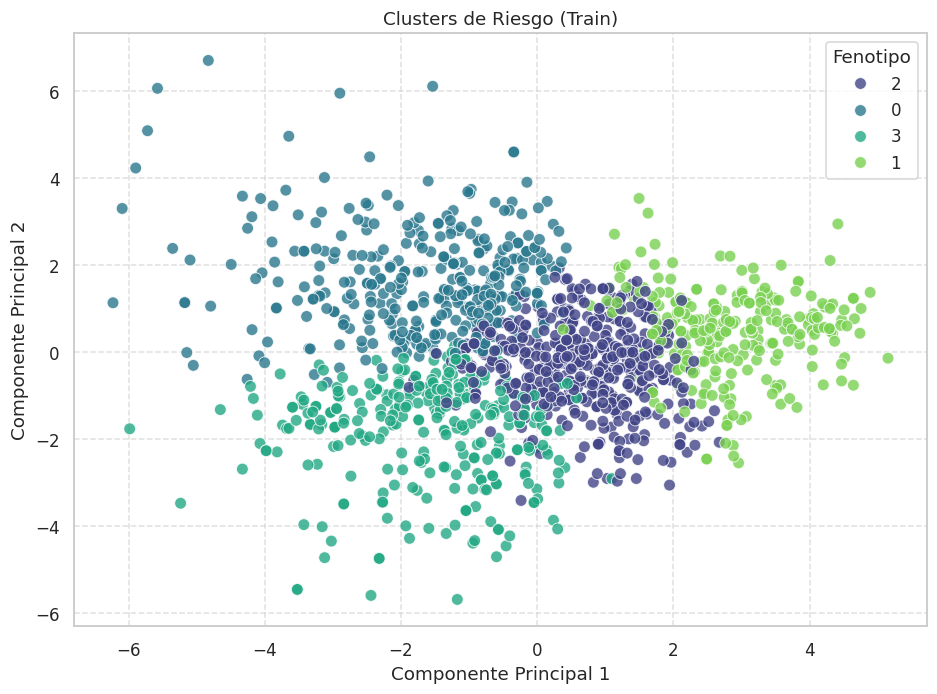

In [40]:
import pandas as pd
df_pca_plot = pd.DataFrame(X_train_pca[:, :2], columns=['PC1', 'PC2'])
df_pca_plot['Cluster'] = y_train.astype(str).tolist()
# Using generic cluster names instead of specific ones for flexibility with k
# df_pca_plot['Cluster'] = df_pca_plot['Cluster'].map({
#     '0': 'Cardiovascular',
#     '1': 'Control-bajo riesgo',
#     '2': 'Cardio-metabolico'
#     '3': Cardio-renal
# })

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca_plot,
                palette='viridis', s=60, alpha=0.8)
plt.title('Clusters de Riesgo (Train)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Fenotipo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

2. Por 2 componentes principales

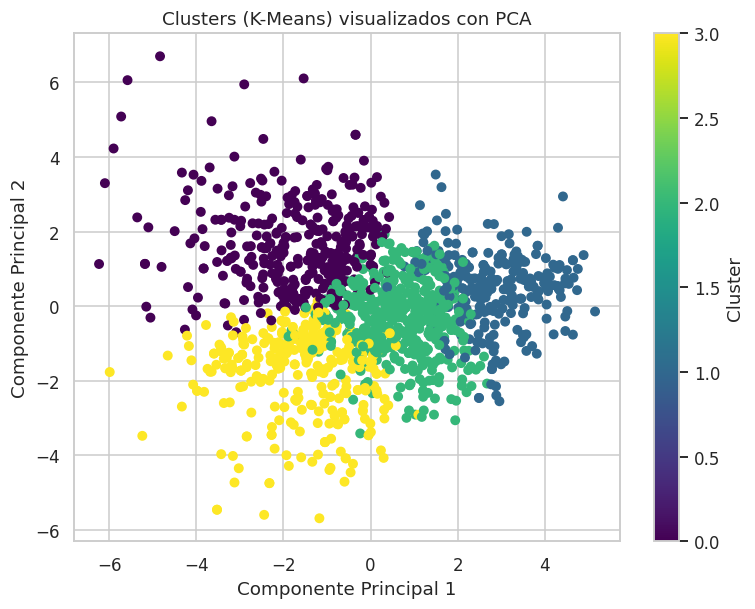

In [41]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Graficar
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='viridis', s=30)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters (K-Means) visualizados con PCA')
plt.colorbar(label='Cluster')
plt.show()

## Cruva de aprendizaje de random forest

<Figure size 1100x550 with 0 Axes>

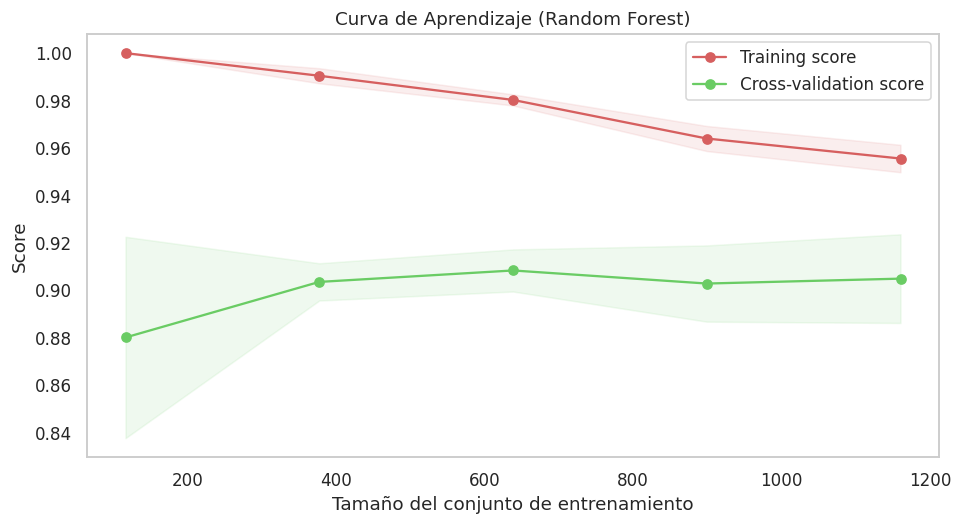

In [42]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 5))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel('Tamaño del conjunto de entrenamiento')
    axes.set_ylabel('Score')

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color='r')
    axes.plot(train_sizes, train_scores_mean, 'o-', color='r',
                 label='Training score')
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color='g')
    axes.plot(train_sizes, test_scores_mean, 'o-', color='g',
                 label='Cross-validation score')
    axes.legend(loc='best')
    return plt

# Configurar el Random Forest Classifier con los parámetros finales
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

# Plotear la curva de aprendizaje para Random Forest
plt.figure(figsize=(10, 5))
plot_learning_curve(rf_final, 'Curva de Aprendizaje (Random Forest)', X_train_pca, y_train, cv=5, n_jobs=-1)
plt.show()

## Validación interna

### ANNOVA

In [43]:
from scipy.stats import f_oneway

variables = [
    'ldl',
    'c_total',
    'trigliceridos',
    'glucosa',
    'creatinina',
    'TFG',
    'imc',
    'ta_sistolica'
]

print("ANOVA ENTRE CLUSTERS\n")

# Ensure df_train exists and has a 'Cluster' column
if 'df_train' in locals() and 'Cluster' in df_train.columns:
    # Get the unique cluster labels
    unique_clusters = sorted(df_train['Cluster'].unique())

    for var in variables:
        grupos = []
        for cluster_id in unique_clusters:
            grupos.append(df_train[df_train['Cluster'] == cluster_id][var].dropna())

        # Check if there's enough data in at least two groups to perform ANOVA
        valid_grupos = [g for g in grupos if len(g) > 1]

        if len(valid_grupos) >= 2:
            f_stat, p_val = f_oneway(*valid_grupos)

            print(f"{var}")
            print(f"F-statistic: {f_stat:.4f}")
            print(f"p-value: {p_val:.10f}")

            if p_val < 0.05:
                print("Diferencia significativa entre clusters\n")
            else:
                print("No hay diferencia significativa\n")
        else:
            print(f"{var}: No hay suficientes grupos con datos para realizar ANOVA.\n")
else:
    print("Error: 'df_train' o la columna 'Cluster' no existen. Asegúrate de que los pasos de clustering se hayan ejecutado previamente.")

ANOVA ENTRE CLUSTERS

ldl
F-statistic: 458.3952
p-value: 0.0000000000
Diferencia significativa entre clusters

c_total
F-statistic: 582.6238
p-value: 0.0000000000
Diferencia significativa entre clusters

trigliceridos
F-statistic: 90.7262
p-value: 0.0000000000
Diferencia significativa entre clusters

glucosa
F-statistic: 23.8201
p-value: 0.0000000000
Diferencia significativa entre clusters

creatinina
F-statistic: 436.6578
p-value: 0.0000000000
Diferencia significativa entre clusters

TFG
F-statistic: 772.4149
p-value: 0.0000000000
Diferencia significativa entre clusters

imc
F-statistic: 136.1219
p-value: 0.0000000000
Diferencia significativa entre clusters

ta_sistolica
F-statistic: 159.1131
p-value: 0.0000000000
Diferencia significativa entre clusters



In [44]:
anova_results = {
    'Variable': ['TFG', 'c_total', 'ldl', 'creatinina',
                 'ta_sistolica', 'imc', 'trigliceridos', 'glucosa'],

    'F_statistic': [772.41, 582.62, 458.39, 436.65,
                    159.11, 136.12, 90.72, 23.82]
}

import pandas as pd

anova_df = pd.DataFrame(anova_results)

anova_df = anova_df.sort_values(by='F_statistic', ascending=False)

print(anova_df)

        Variable  F_statistic
0            TFG       772.41
1        c_total       582.62
2            ldl       458.39
3     creatinina       436.65
4   ta_sistolica       159.11
5            imc       136.12
6  trigliceridos        90.72
7        glucosa        23.82


## Validación externa

In [45]:
import pandas as pd
import numpy as np

# 1. Cargar y limpiar filas basura
df_ext = pd.read_excel('/content/PACIENTES_VALIDACIÓN_ANON.xlsx')
df_ext = df_ext[pd.to_numeric(df_ext['Edad'], errors='coerce').notna()].copy()
df_ext = df_ext.reset_index(drop=True)
print(f"Pacientes reales cargados: {len(df_ext)}")

# 2. Renombrar columnas
column_rename_map = {
    'Edad': 'edad', 'Talla': 'talla',
    'Presion_Sistolica': 'ta_sistolica', 'Presion_Diastolica': 'ta_diastolica',
    'IMC': 'imc', 'COLESTEROL TOTAL': 'c_total', 'HDL': 'hdl', 'LDL': 'ldl',
    'TRIGLICERIDOS': 'trigliceridos', 'GLUCOSA EN SUERO': 'glucosa',
    'CREATININA EN SUERO': 'creatinina', 'CELULAS MEDIAS': 'celulas_medias',
    'GRANULOCITOS': 'granulocitos', 'LINFOCITOS': 'linfocitos',
    'PLAQUETAS': 'plaquetas', 'LEUCOCITOS': 'leucocitos',
    'HEMOGLOBINA': 'hemoglobina', 'HEMATOCRITO': 'hematocrito',
}
df_ext = df_ext.rename(columns=column_rename_map)

# 3. Codificar categóricas → numérico ANTES de cualquier comparación
df_ext['sexo'] = df_ext['Sexo'].str.upper().str.strip().map({'FEMENINO': 0, 'MASCULINO': 1})
df_ext['ap_hipertension'] = df_ext['ap_hipertension'].str.strip().map({'Si': 1, 'No': 0})

# 4. Talla cm → metros
df_ext['talla'] = pd.to_numeric(df_ext['talla'], errors='coerce') / 100

# 5. Peso calculado desde IMC y talla (metros)
df_ext['imc'] = pd.to_numeric(df_ext['imc'], errors='coerce')
df_ext['peso'] = df_ext['imc'] * (df_ext['talla'] ** 2)

# 6. Ensure df_ext has the exact columns required for the imputer (cols_numericas)
#    and the subsequent scaler/PCA (X_train.columns)

# First, align df_ext to X_train.columns (which is df_modelo's columns, after drops)
# Add missing columns with NaN
for col in X_train.columns:
    if col not in df_ext.columns:
        df_ext[col] = np.nan

# Drop columns from df_ext that are not in X_train.columns
df_ext = df_ext[X_train.columns.tolist()]


# 7. Convert ALL columns to numeric (after ensuring proper column set)
for col in df_ext.columns:
    df_ext[col] = pd.to_numeric(df_ext[col], errors='coerce')

# 8. Limpieza por rangos clínicos
rangos = {
    'c_total': (50, 500), 'creatinina': (0.3, 20), 'glucosa': (30, 600),
    'hdl': (10, 150), 'hematocrito': (10, 65), 'hemoglobina': (3, 25),
    'ldl': (10, 400), 'trigliceridos': (20, 1000), 'edad': (0, 110),
    'ta_sistolica': (60, 250), 'ta_diastolica': (30, 150),
    'peso': (20, 200), 'talla': (1.0, 2.20), 'imc': (10, 70), 'TFG': (1, 200),
}
for col, (minv, maxv) in rangos.items():
    if col in df_ext.columns:
        df_ext.loc[(df_ext[col] < minv) | (df_ext[col] > maxv), col] = np.nan

# 9. Imputación KNN — using the cols_numericas that the imputer was fitted on
df_ext[cols_numericas] = imputer.transform(df_ext[cols_numericas])

# 10. Winsorización
df_ext = winsorizar_expert(df_ext)

# 11. Estandarización y PCA
X_ext = df_ext.copy() # df_ext now already has the correct columns and order
X_ext_scaled = scaler.transform(X_ext)
X_ext_pca = pca_final.transform(X_ext_scaled)

# 12. Predicción
y_ext_pred = rf.predict(X_ext_pca)
df_ext['Cluster_Predicho'] = y_ext_pred
mapa_nombres = {0: 'cardiovascular', 1: 'Bajo riesgo', 2: 'cardiometabolico', 3: 'cardiorenal'}
df_ext['Fenotipo'] = df_ext['Cluster_Predicho'].map(mapa_nombres)

# 13. Resultados
print(f"\nTotal pacientes clasificados: {len(df_ext)}")
print("\nDistribución de fenotipos:")
print(df_ext['Fenotipo'].value_counts())
display(df_ext[['edad', 'sexo', 'ta_sistolica', 'ldl', 'hdl', 'imc', 'Cluster_Predicho', 'Fenotipo']].head(10))

FileNotFoundError: [Errno 2] No such file or directory: '/content/PACIENTES_VALIDACIÓN_ANON.xlsx'

In [ ]:
# ============================================================
# MAPEO DE FENOTIPOS
# ============================================================

mapa_nombres = {
    0: 'Cardiovascular',
    1: 'Bajo riesgo',
    2: 'Cardiometabolico',
    3: 'Cardiorrenal'
}

df_ext['Fenotipo'] = df_ext['Cluster_Predicho'].map(mapa_nombres)

# ============================================================
# EXPORTAR RESULTADOS
# ============================================================

cols_exportar = [
    'edad',
    'Cluster_Predicho',
    'Fenotipo'
]

df_resultado = df_ext[cols_exportar].copy()

df_resultado.to_csv(
    'predicciones_validacion2.csv',
    index=False
)

print("\n✔ Archivo exportado correctamente")

Serialización (exportar todos los artefactos)


In [46]:
import pickle
import os

os.makedirs('/content/models_artery', exist_ok=True)

# Serializar todos los artefactos del pipeline
with open('/content/models_artery/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('/content/models_artery/pca.pkl', 'wb') as f:
    pickle.dump(pca_final, f)

with open('/content/models_artery/kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

with open('/content/models_artery/random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('/content/models_artery/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

# Guardar también las columnas exactas que espera el modelo
columnas_modelo = list(X_train.columns)
with open('/content/models_artery/columnas_modelo.pkl', 'wb') as f:
    pickle.dump(columnas_modelo, f)

print("Artefactos exportados:")
for f in os.listdir('/content/models_artery'):
    size = os.path.getsize(f'/content/models_artery/{f}')
    print(f"  {f} — {size/1024:.1f} KB")

Artefactos exportados:
  kmeans.pkl — 6.6 KB
  imputer.pkl — 303.6 KB
  columnas_modelo.pkl — 0.2 KB
  random_forest.pkl — 854.2 KB
  pca.pkl — 3.0 KB
  scaler.pkl — 1.2 KB


Prueba de inferencia con un paciente simulado


In [47]:
import pandas as pd
import numpy as np
import pickle

# Mapa de fenotipos (igual que en el notebook final)
mapa_fenotipos = {
    0: 'Cardiovascular',
    1: 'Bajo riesgo',
    2: 'Cardiometabólico',
    3: 'Cardiorrenal'
}

descripciones = {
    0: 'Alteración lipídica predominante con riesgo cardiovascular elevado. Seguimiento cardiológico recomendado.',
    1: 'Perfil de bajo riesgo. Mantener hábitos saludables y revisión anual.',
    2: 'Resistencia metabólica + perfil lipídico alterado. Control metabólico y seguimiento endocrinológico.',
    3: 'Disfunción renal + alteración lipídica. Nefrología + manejo agresivo de lípidos.'
}

# Paciente de prueba — valores típicos en unidades del modelo
# talla en METROS, peso en kg, TFG calculada
paciente_raw = {
    'c_total':       190.0,
    'creatinina':    1.1,
    'glucosa':       105.0,
    'hdl':           45.0,
    'hemoglobina':   14.5,
    'ldl':           120.0,
    'leucocitos':    7.2,
    'plaquetas':     250.0,
    'trigliceridos': 160.0,
    'edad':          55.0,
    'sexo':          1,        # 1 = masculino
    'zona':          1,        # 1 = urbana
    'ap_hipertension': 1,      # 1 = sí
    'ta_sistolica':  145.0,
    'ta_diastolica': 90.0,
    'peso':          80.0,
    'talla':         1.72,     # metros
    'imc':           27.0,
    'TFG':           75.0,
}

# Construir DataFrame con columnas en el orden exacto del entrenamiento
paciente_df = pd.DataFrame([paciente_raw])[columnas_modelo]

print("Columnas del paciente:", list(paciente_df.columns))
print("Shape:", paciente_df.shape)

Columnas del paciente: ['c_total', 'creatinina', 'glucosa', 'hdl', 'hemoglobina', 'ldl', 'leucocitos', 'plaquetas', 'trigliceridos', 'edad', 'sexo', 'zona', 'ap_hipertension', 'ta_sistolica', 'ta_diastolica', 'peso', 'talla', 'imc', 'TFG']
Shape: (1, 19)


Pipeline de inferencia completo

In [48]:
def predecir_paciente(paciente_df, imputer, scaler, pca_final, rf, columnas_modelo):
    """
    Recibe un DataFrame de 1 fila con las columnas del modelo
    y devuelve cluster, fenotipo, probabilidades y descripción.
    """

    # 1. Asegurar orden de columnas
    paciente_df = paciente_df[columnas_modelo].copy()

    # 2. Winsorización con límites expertos
    limites = {
        'c_total':       (0,     550.0),
        'creatinina':    (0,     2.0),
        'glucosa':       (25.0,  492.0),
        'hdl':           (0,     120.0),
        'hemoglobina':   (7.0,   21.0),
        'ldl':           (0,     404.6),
        'trigliceridos': (0,     420.0),
        'edad':          (6,     110),
        'ta_sistolica':  (60.5,  220.0),
        'ta_diastolica': (40.0,  120.0),
        'peso':          (9.0,   170.0),
        'talla':         (1.27,  1.97),
        'imc':           (4.51,  60.0),
        'TFG':           (11.47, 197.39),
    }
    for var, (lo, hi) in limites.items():
        if var in paciente_df.columns:
            paciente_df[var] = paciente_df[var].clip(lower=lo, upper=hi)

    # 3. Imputación KNN (por si llega algún nulo)
    cols_num = paciente_df.select_dtypes(include=[np.number]).columns.tolist()
    paciente_df[cols_num] = imputer.transform(paciente_df[cols_num])

    # 4. Estandarización
    paciente_scaled = scaler.transform(paciente_df)

    # 5. PCA
    paciente_pca = pca_final.transform(paciente_scaled)

    # 6. Predicción
    cluster_pred  = int(rf.predict(paciente_pca)[0])
    probabilidades = rf.predict_proba(paciente_pca)[0]

    return {
        'cluster_predicho':  cluster_pred,
        'fenotipo':          mapa_fenotipos[cluster_pred],
        'descripcion':       descripciones[cluster_pred],
        'probabilidades':    {
            mapa_fenotipos[i]: round(float(p), 4)
            for i, p in enumerate(probabilidades)
        }
    }


# Ejecutar
resultado = predecir_paciente(paciente_df, imputer, scaler, pca_final, rf, columnas_modelo)

print("\n===== RESULTADO ARTERY-VA =====")
print(f"Cluster:   {resultado['cluster_predicho']}")
print(f"Fenotipo:  {resultado['fenotipo']}")
print(f"Descripción: {resultado['descripcion']}")
print("\nProbabilidades por fenotipo:")
for fenotipo, prob in resultado['probabilidades'].items():
    barra = '█' * int(prob * 30)
    print(f"  {fenotipo:<25} {prob:.2%}  {barra}")


===== RESULTADO ARTERY-VA =====
Cluster:   3
Fenotipo:  Cardiorrenal
Descripción: Disfunción renal + alteración lipídica. Nefrología + manejo agresivo de lípidos.

Probabilidades por fenotipo:
  Cardiovascular            10.14%  ███
  Bajo riesgo               1.86%  
  Cardiometabólico          7.85%  ██
  Cardiorrenal              80.14%  ████████████████████████


Verificación de los .pkl (carga y sanity check)


In [49]:
# Cargar desde disco y verificar que todo funciona igual
with open('/content/models_artery/scaler.pkl',         'rb') as f: scaler_v    = pickle.load(f)
with open('/content/models_artery/pca.pkl',            'rb') as f: pca_v       = pickle.load(f)
with open('/content/models_artery/random_forest.pkl',  'rb') as f: rf_v        = pickle.load(f)
with open('/content/models_artery/imputer.pkl',        'rb') as f: imputer_v   = pickle.load(f)
with open('/content/models_artery/columnas_modelo.pkl','rb') as f: columnas_v  = pickle.load(f)

# Re-ejecutar inferencia con los artefactos cargados
resultado_v = predecir_paciente(paciente_df, imputer_v, scaler_v, pca_v, rf_v, columnas_v)

# Comparar resultados
assert resultado['cluster_predicho'] == resultado_v['cluster_predicho'], "❌ Cluster distinto tras cargar PKL"
assert resultado['probabilidades']   == resultado_v['probabilidades'],   "❌ Probabilidades distintas"

print("✅ Sanity check OK — los .pkl reproducen exactamente el mismo resultado")
print(f"   Fenotipo: {resultado_v['fenotipo']}")
print(f"   Probabilidades: {resultado_v['probabilidades']}")

✅ Sanity check OK — los .pkl reproducen exactamente el mismo resultado
   Fenotipo: Cardiorrenal
   Probabilidades: {'Cardiovascular': 0.1014, 'Bajo riesgo': 0.0186, 'Cardiometabólico': 0.0785, 'Cardiorrenal': 0.8014}


Descarga de los artefactos

In [50]:
from google.colab import files
import zipfile

zip_path = '/content/models_artery.zip'
with zipfile.ZipFile(zip_path, 'w') as zf:
    for fname in os.listdir('/content/models_artery'):
        zf.write(f'/content/models_artery/{fname}', fname)

files.download(zip_path)
print("✅ ZIP descargado")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ ZIP descargado
